**About NETFLIX**

Netflix is one of the most popular media and video streaming platforms. They have over 10000 movies or tv shows available on their platform, as of mid-2021, they have over 222M Subscribers globally. This tabular dataset consists of listings of all the movies and tv shows available on Netflix, along with details such as - cast, directors, ratings, release year, duration, etc.

**Business Problem**

Analyze the data and generate insights that could help Netflix in deciding which type of shows/movies to produce and how they can grow the business in different countries

#**1.Defining Problem Statement and Analysing basic metrics**

**Importing libraries**

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Original dataset importing**

In [54]:
# Notice the r - raw string to escape the escape charachter "\"
df = pd.read_csv("/content/netflix.csv")

#**2.Observations on the shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), missing value detection, statistical summary**

**Getting shape of data**

In [55]:
df.shape

(8807, 12)

**Getting dataset info**


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


**What are the columns ?**

In [57]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

**Getting Statistical Data**

The Current dataset mostly has categorical data, only few columns with numerical data are available

In [58]:
df['release_year'].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

**Summary statistics for non-numeric columns:**

In [59]:
df.describe(include=['object'])

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


**Or using df.describe() for combined summary**

In [60]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


**Analysing what kind of data is available using 10 sample rows**

It can be observed that comma separated data (mutiple data ) is available in many columns like  director,cast,country, listed_in columns, and there are many null values present.

We will have to handle each of them separately.

In [61]:
df.sample(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1874,s1875,Movie,Bigflo & Oli: Hip Hop Frenzy,"Bigflo & Oli, Jérémie Levypon",Bigflo & Oli,France,"October 8, 2020",2020,TV-MA,100 min,"Documentaries, International Movies, Music & M...",Go backstage with French rap duo Bigflo & Oli ...
4931,s4932,Movie,Pickpockets,Peter Webber,"Carlos Bardem, Natalia Reyes, Emiliano Pernia,...",Colombia,"April 12, 2018",2017,TV-MA,108 min,"Dramas, Independent Movies, International Movies",Aspiring teen thieves learn what it takes to b...
6240,s6241,Movie,Barbie: Princess Charm School,Ezekiel Norton,"Diana Kaarina, Morwenna Banks, Nicole Oliver, ...","United States, Canada","October 1, 2017",2011,TV-Y,80 min,Children & Family Movies,Blair Willows is excited when she gets to go t...
717,s718,Movie,Headspace: Unwind Your Mind,NaN,"Andy Puddicombe, Evelyn Lewis Prieto, Ginger D...",NaN,"June 15, 2021",2021,TV-G,273 min,Documentaries,"Do you want to relax, meditate or sleep deeply..."
2590,s2591,TV Show,Reckoning,NaN,"Aden Young, Sam Trammell, Simone Kessell, Laur...","Australia, United States","May 1, 2020",2019,TV-MA,1 Season,"Crime TV Shows, TV Dramas, TV Mysteries","When a local teen is murdered in their quiet, ..."
3293,s3294,TV Show,Little Things,NaN,"Dhruv Sehgal, Mithila Palkar",India,"November 9, 2019",2019,TV-MA,3 Seasons,"International TV Shows, Romantic TV Shows, TV ...",A cohabiting couple in their 20s navigate the ...
5555,s5556,TV Show,Hoff the Record,Gordon Anderson,"David Hasselhoff, Asim Chaudhry, Fergus Craig,...",United Kingdom,"March 31, 2017",2016,TV-MA,2 Seasons,"British TV Shows, TV Comedies",TV star David Hasselhoff hopes to reboot his c...
6861,s6862,Movie,God's Not Dead,Harold Cronk,"Kevin Sorbo, Shane Harper, David A.R. White, D...",United States,"April 1, 2020",2014,PG,113 min,"Dramas, Faith & Spirituality",A spiritual college student clashes with an at...
3372,s3373,Movie,Dolemite Is My Name,Craig Brewer,"Eddie Murphy, Wesley Snipes, Keegan-Michael Ke...",United States,"October 25, 2019",2019,R,118 min,"Comedies, Dramas","In 1970s LA, struggling comedian Rudy Ray Moor..."
271,s272,TV Show,Brand New Cherry Flavor,NaN,"Rosa Salazar, Eric Lange, Catherine Keener, Je...",United States,"August 13, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",A filmmaker heads to Hollywood in the early '9...


#**3.Checking the null values present in different columns**

In [62]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

#**4.Handling null values/Filling missing values**

As a rule of thumb we can drop 5% of data if more than 40% of values in a
column/row are missing !!

As this is not the case here , we will try to fill the missing values.

In the replace() method, both the to_replace and value parameters expect lists, even if you are only replacing a single value. This is a requirement of the method's signature

## **a.Column- director,cast :Dealing with Director and Cast column nulls:**

For director and cast column ,we will fill '**Unknown Director**' and **'Unknown Actor'** respectively for missing/anonymous values

In [63]:
df["director"]=df["director"].fillna(value='Unknown Director')
df["cast"]=df["cast"].fillna(value='Unknown Actor')


## **b.Column: Rating**

Treatment for null values

In [64]:
df[df["rating"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,Unknown Director,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,Unknown Director,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,Unknown Director,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [65]:
df["rating"] = df["rating"].fillna(value="Rating Not Available")

## **c.Column 'duration:Dealing with null duration**

We will replace null duration with string 0 min

In [66]:
df["duration"]= df["duration"].fillna(value="0 min")

In [67]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country         831
date_added       10
release_year      0
rating            0
duration          0
listed_in         0
description       0
dtype: int64

# **d.Column: 'date_added' :Dealing with null values in date_added column**

We can fill nulls with mode value for 'date_added' column

In [68]:
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])

In [69]:
# Checking if all nulls taken care of:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country         831
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
dtype: int64

#**Basic Analysis** - **Data Cleaning**





## **A. Un-nesting the columns**

### **1.Un-nesting of 'director' column**

In [70]:
df_director_raw = pd.DataFrame(df["director"].apply(lambda x : str(x).split(",")).tolist(),index = df["title"])
#Note : The dataframe needs a 2D list to be passed as data , index - title column has been set as index

In [71]:
# Now for each index : i.e Movie name : There is a row of all the directors under columns 0,1,2,3,4....
# We need to stack them ( to get : movie name - 1st director
#                                  movie name - 2nd director
#                                  movie name - 3rd director )


In [72]:
df_director = df_director_raw.stack().reset_index()
df_director.drop('level_1', axis = 1, inplace = True)
df_director.rename(columns ={0:'director'}, inplace = True)
df_director['director'] = df_director['director'].str.strip() # Removing leading and trailing whitespaces
df_director.sample(10)

,title,director
742,The Judgement,Unknown Director
1885,Ya no estoy aquí: Una conversación entre Guill...,Unknown Director
8116,Money,Martin Rosete
3935,Boi,Jorge M. Fontana
5023,Once Again,Kanwal Sethi
622,Dreamy Eyes,Victor Vu
2397,Gigantosaurus,Unknown Director
2422,Mama's Boy,Amro Salah
511,Heist,Unknown Director
4910,Delhi 6,Rakeysh Omprakash Mehra


### **2. Un-nesting the 2nd column : cast**

In [73]:
df_cast_raw = pd.DataFrame(df["cast"].apply(lambda x:str(x).split(",")).tolist(),index=df["title"])
df_cast = df_cast_raw.stack().reset_index()
df_cast.drop('level_1', axis = 1, inplace = True)
df_cast.rename(columns ={0:'cast'}, inplace = True)
df_cast['cast'] = df_cast['cast'].str.strip()    # Removing leading ,trailing white spaces
df_cast.sample(10)

,title,cast
31461,Everyday I Love You,Ariel Rivera
60376,The Assignment,Adrian Hough
27799,Kill Me If You Dare,Seda Güven
49866,Fall Girls,J-Boog
21239,The Legacy of the Bones,Alicia Sánchez
60604,The Bye Bye Man,Douglas Smith
61198,The Foreigner,Pierce Brosnan
53010,Kay Dyache Bola,Umesh Kamat
13499,Machete Kills,Sofía Vergara
4628,Holiday on Mars,Francesco Bruni


### **3.Un-nesting the listed_in column using explode() directly in df dataset**

**Also renaming it to 'genre' for better understanding**

Exploring a new way of un-nesting

In [74]:
# Convert string values to lists by splitting on commas
df['listed_in'] = df['listed_in'].str.split(', ')


# Explode the column
df = df.explode('listed_in')

# Renaming this column to 'genre'
df.rename(columns={'listed_in': 'genre'}, inplace=True)


### **4.Un-nesting the country column using explode() directly in df dataset**

Exploring a new way of un-nesting - Explode

In [75]:
df['country']= df['country'].str.split(',')
df = df.explode('country')


### **5.Merging the datasets**

In [76]:
df_interim = df_director.merge(df_cast,on='title',how='inner')

In [77]:
df_interim.sample(10)

,title,director,cast
52967,Don Quixote: The Ingenious Gentleman of La Mancha,Jon YonKondy,Luis Guzman
15103,Prom Night,Nelson McCormick,James Ransone
11482,Wave of Cinema: Surat dari Timur,Saron Sakina,Molukka Hiphop Community
62960,Remember Me,Allen Coulter,Emilie de Ravin
25222,Arrow,James Bamford,Katie Cassidy
29756,Vagabond,Unknown Director,Lee Ki-young
19293,The Millions,Toka McBaror,Blossom Chukwujekwu
51524,Charlotte's Web,Charles A. Nichols,Dave Madden
31520,Beats,Chris Robinson,Emayatzy Corinealdi
55156,Hamburger Hill,John Irvin,Don Cheadle


### **6.Merging the new df with all the remaining columns to get the final dataframe**

In [78]:
df_final =df_interim.merge(df[['show_id', 'type','title', 'country','date_added',
                          'release_year', 'rating', 'duration','genre', 'description']], on =['title'], how ='left' )
df_final.sample(10)

,title,director,cast,show_id,type,country,date_added,release_year,rating,duration,genre,description
54316,Tanu Weds Manu,Aanand Rai,Deepak Dobriyal,s2291,Movie,India,"July 5, 2020",2011,TV-14,114 min,Comedies,When London-based doctor Manu reluctantly retu...
45041,The 100,Unknown Director,Lindsey Morgan,s1879,TV Show,Canada,"October 8, 2020",2020,TV-MA,7 Seasons,TV Sci-Fi & Fantasy,A century after Earth was devastated by a nucl...
101480,Line Walker,Jazz Boon,Cheng Taishen,s4343,Movie,Hong Kong,"December 1, 2018",2016,TV-MA,109 min,Dramas,A Hong Kong intelligence officer tasked with f...
129579,Mariah Carey's Merriest Christmas,James Yukich,Fina Strazza,s5682,Movie,United States,"December 9, 2016",2015,TV-G,38 min,Music & Musicals,Pop music superstar Mariah Carey hosts this al...
126582,Louis C.K. 2017,Louis C.K.,Louis C.K.,s5542,Movie,United States,"April 4, 2017",2017,74 min,0 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
128116,"Michael Bolton's Big, Sexy Valentine's Day Spe...",Akiva Schaffer,Mary Holland,s5614,Movie,United States,"February 7, 2017",2017,TV-MA,54 min,Music & Musicals,"After Santa tells him he needs 75,000 new babi..."
136338,A Haunted House,Michael Tiddes,Cedric the Entertainer,s6040,Movie,United States,"February 21, 2020",2013,R,86 min,Horror Movies,This spoof on scary movies follows a young cou...
7226,Quam's Money,Kayode Kasum,Jemima Osunde,s299,Movie,Nigeria,"August 6, 2021",2020,TV-MA,115 min,International Movies,"In this sequel to ""New Money,"" Quam, a securit..."
139859,ATM,Mez Tharatorn,Puttachat Pongsuchat,s6194,Movie,Canada,"September 5, 2018",2012,TV-14,122 min,Comedies,"When a broken ATM dishes out a fortune, a coup..."
153112,Final Destination 2,David R. Ellis,Justina Machado,s6755,Movie,United States,"January 1, 2020",2003,R,90 min,Thrillers,"On a road trip with friends, Kimberly has a pr..."


#**Data Hygiene Check can be done using value_counts() for each column**

### **1.Cleaning 'country' column using strip() to remove leading trailing white spaces**

In [79]:
df_final['country'] = df_final['country'].str.strip()

In [80]:
df_final['country'].isnull().sum()

11897

As the 'director' column was nested so we couldn't find the mode for country.

Now its un-nested so we can handle the null values in 'country' column

In [81]:
# Group by 'director'and calculate the mode of country for each director',
# If mode is empty use - use mode for whole country column i.e United States
# If there are mutiple modes take the first one

# mode for whole country column:
mode_country = df_final['country'].mode()[0]
# print(mode_country)    # United Sates

# mode for country by director:
mode_country_by_director = df_final.groupby('director')['country'].transform(lambda x: mode_country if x.mode().empty else x.mode()[0])
# print(mode_country_by_director)


# Fill NaN values in the country column with the mode of country for each director
df_final['country'] = df_final['country'].fillna(mode_country_by_director)
df_final.head(10)

,title,director,cast,show_id,type,country,date_added,release_year,rating,duration,genre,description
0,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,s1,Movie,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,Blood & Water,Unknown Director,Ama Qamata,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
2,Blood & Water,Unknown Director,Ama Qamata,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
3,Blood & Water,Unknown Director,Ama Qamata,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
4,Blood & Water,Unknown Director,Khosi Ngema,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
5,Blood & Water,Unknown Director,Khosi Ngema,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
6,Blood & Water,Unknown Director,Khosi Ngema,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
7,Blood & Water,Unknown Director,Gail Mabalane,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
8,Blood & Water,Unknown Director,Gail Mabalane,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
9,Blood & Water,Unknown Director,Gail Mabalane,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."


### **2.Cleaning 'rating' column**

In [82]:
df_final[df_final["rating"].isin(["74 min","84 min","66 min"])]

,title,director,cast,show_id,type,country,date_added,release_year,rating,duration,genre,description
126582,Louis C.K. 2017,Louis C.K.,Louis C.K.,s5542,Movie,United States,"April 4, 2017",2017,74 min,0 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
131648,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,s5795,Movie,United States,"September 16, 2016",2010,84 min,0 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
131782,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,s5814,Movie,United States,"August 15, 2016",2015,66 min,0 min,Movies,The comic puts his trademark hilarious/thought...


**a.First we will copy values from rating column to make corresponding duration
entries**






In [83]:
df_final.loc[df_final["rating"].isin(["74 min","84 min","66 min"]),'duration']=   df_final.loc[df_final["rating"].isin(["74 min","84 min","66 min"]),'rating']

**b.Replacing rating with the mode value TV-MA , also Louis C.K's content is for mature audience ....justifies the TV-MA rating**

In [84]:
df_final['rating'] = df_final['rating'].replace({"74 min":"TV-MA" ,"84 min":"TV-MA" ,"66 min":"TV-MA"  })

In [85]:
df_final.loc[[126582, 131648, 131782]]


,title,director,cast,show_id,type,country,date_added,release_year,rating,duration,genre,description
126582,Louis C.K. 2017,Louis C.K.,Louis C.K.,s5542,Movie,United States,"April 4, 2017",2017,TV-MA,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
131648,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,s5795,Movie,United States,"September 16, 2016",2010,TV-MA,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
131782,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,s5814,Movie,United States,"August 15, 2016",2015,TV-MA,66 min,Movies,The comic puts his trademark hilarious/thought...


**3.Cleaning 'duration' column :Getting the numerical part from duration making it easy for processing**

Make sure that while using fillna the value is string = 0 mins otherwise split or extract ...both won't work

In [86]:
df_final['new_duration']=df_final['duration'].str.split(' ').str[0].astype(int)


# Another method
#df_final['duration_new'] = df_final['duration'].str.extract('(\d+)').astype(int)
#df_final["duration_new"]

### **4.Splitting Column 'date_added' into date , year , month to be able to better analyse the data**

In [87]:
df_final["date_added"].value_counts()

date_added
January 1, 2020       3888
November 1, 2019      2229
July 1, 2021          2219
October 1, 2017       1899
September 1, 2021     1756
                      ... 
May 24, 2018             1
August 8, 2017           1
October 10, 2017         1
February 4, 2008         1
September 25, 2021       1
Name: count, Length: 1767, dtype: int64

In [88]:
df_final.sample(3)

,title,director,cast,show_id,type,country,date_added,release_year,rating,duration,genre,description,new_duration
120661,The Lion Woman,Vibeke Idsøe,Ida Ursin-Holm,s5249,Movie,Germany,"October 1, 2017",2016,TV-14,118 min,International Movies,A girl born with a condition that causes abnor...,118
100571,Tidelands,Unknown Director,Peter O'Brien,s4310,TV Show,Australia,"December 14, 2018",2018,TV-MA,1 Season,International TV Shows,Ex-con Cal McTeer's return to her hometown of ...,1
136030,7 Din Mohabbat In,Farjad Nabi,Adnan Shah,s6026,Movie,Pakistan,"May 15, 2019",2018,TV-PG,137 min,Comedies,Given just seven days by a genie to find a gir...,137


In [89]:
df_final["date_when_added"] = pd.to_datetime(df_final["date_added"].str.strip())

In [90]:
df_final['year_added'] = df_final['date_when_added'].apply(lambda datetime: datetime.year)
df_final['month_added'] = df_final['date_when_added'].apply(lambda datetime: datetime.month)
df_final['month_name_added'] = df_final['date_when_added'].apply(lambda datetime: datetime.strftime('%b'))
# Extract week of the year using isocalendar().week
df_final['week_added'] = df_final['date_when_added'].dt.isocalendar().week



### **As many duplicates have resulted from un-nesting which may hamper analysing data for certain column , we are creating a duplicate free dataframe**

In [91]:
# Removing duplicates based on 'title' and 'show_id'
no_repeat_df_final =  df_final.drop_duplicates(subset=['title', 'show_id'], keep='first')

In [92]:
df_final.head(10)

,title,director,cast,show_id,type,country,date_added,release_year,rating,duration,genre,description,new_duration,date_when_added,year_added,month_added,month_name_added,week_added
0,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,s1,Movie,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,2021-09-25,2021,9,Sep,38
1,Blood & Water,Unknown Director,Ama Qamata,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2,2021-09-24,2021,9,Sep,38
2,Blood & Water,Unknown Director,Ama Qamata,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2,2021-09-24,2021,9,Sep,38
3,Blood & Water,Unknown Director,Ama Qamata,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2,2021-09-24,2021,9,Sep,38
4,Blood & Water,Unknown Director,Khosi Ngema,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2,2021-09-24,2021,9,Sep,38
5,Blood & Water,Unknown Director,Khosi Ngema,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2,2021-09-24,2021,9,Sep,38
6,Blood & Water,Unknown Director,Khosi Ngema,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2,2021-09-24,2021,9,Sep,38
7,Blood & Water,Unknown Director,Gail Mabalane,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2,2021-09-24,2021,9,Sep,38
8,Blood & Water,Unknown Director,Gail Mabalane,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2,2021-09-24,2021,9,Sep,38
9,Blood & Water,Unknown Director,Gail Mabalane,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2,2021-09-24,2021,9,Sep,38


##**3.Non-Graphical Analysis:  Value counts and unique attributes**



In [93]:
# Getting "Number of unique values" for a given column/feature :

print("Unique values for 'type':", df_final["type"].nunique())
print("Unique values for 'title':", df_final["title"].nunique())
print("Unique values for 'director':", df_final["director"].nunique())
print("Unique values for 'cast':", df_final["cast"].nunique())
print("Unique values for 'country':", df_final["country"].nunique())
print("Unique values for 'date_added':", df_final["date_added"].nunique())
print("Unique values for 'release_year':", df_final["release_year"].nunique())
print("Unique values for 'rating':", df_final["rating"].nunique())
print("Unique values for 'duration':", df_final["duration"].nunique())
print("Unique values for 'genre':", df_final["genre"].nunique())


Unique values for 'type': 2
Unique values for 'title': 8807
Unique values for 'director': 4994
Unique values for 'cast': 36440
Unique values for 'country': 123
Unique values for 'date_added': 1767
Unique values for 'release_year': 74
Unique values for 'rating': 15
Unique values for 'duration': 220
Unique values for 'genre': 42


## **1.Find the counts of each categorical variable both using graphical and non-graphical analysis.**

**1.Column 'type'** - As the original dataset before unnesting and all cleaning etc , there were no null values for type column ..**hence to avoid counting duplicates , it is better to take count on original dataset df**

# **EDA.1.Comparison of tv shows vs. movies.**

### **1.Column 'type'**

In [94]:
# Non Graphical Analysis

df["type"].value_counts()

type
Movie      16883
TV Show     6881
Name: count, dtype: int64

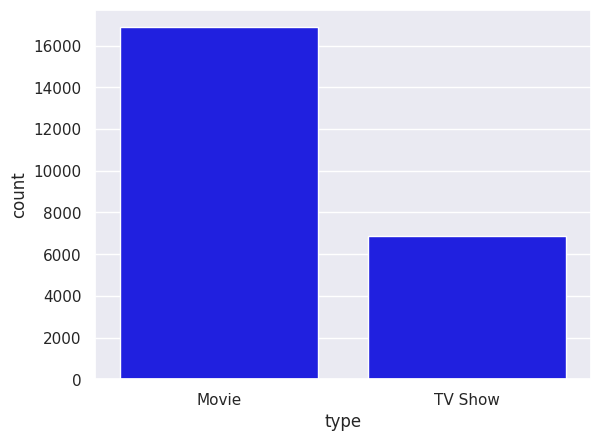

In [95]:
# Graphical Analysis
sns.set_theme(style='darkgrid')
sns.countplot(x='type', data=df, order = df['type'].value_counts().index, color='blue')
plt.show()

## **Observations :**

**Comparison of TV Shows vs. Movies:**

The number of movies on the platform is significantly higher than TV shows on the platform.

### **2.Column 'director' :**
As there are 5121 directors , so getting a countplot for all of them would make analysing difficult

Hence finding the Top 10 , Bottom 10 directors

In [96]:
# Non Graphical Analysis
df_final["director"].value_counts()

director
Unknown Director       50643
Martin Scorsese          419
Youssef Chahine          409
Cathy Garcia-Molina      356
Steven Spielberg         355
                       ...  
Brendon Marotta            1
Charlie Siskel             1
Adam Bolt                  1
Anthony Palmer             1
Kirsten Johnson            1
Name: count, Length: 4994, dtype: int64

In [97]:
df_final["director"].nunique()

4994

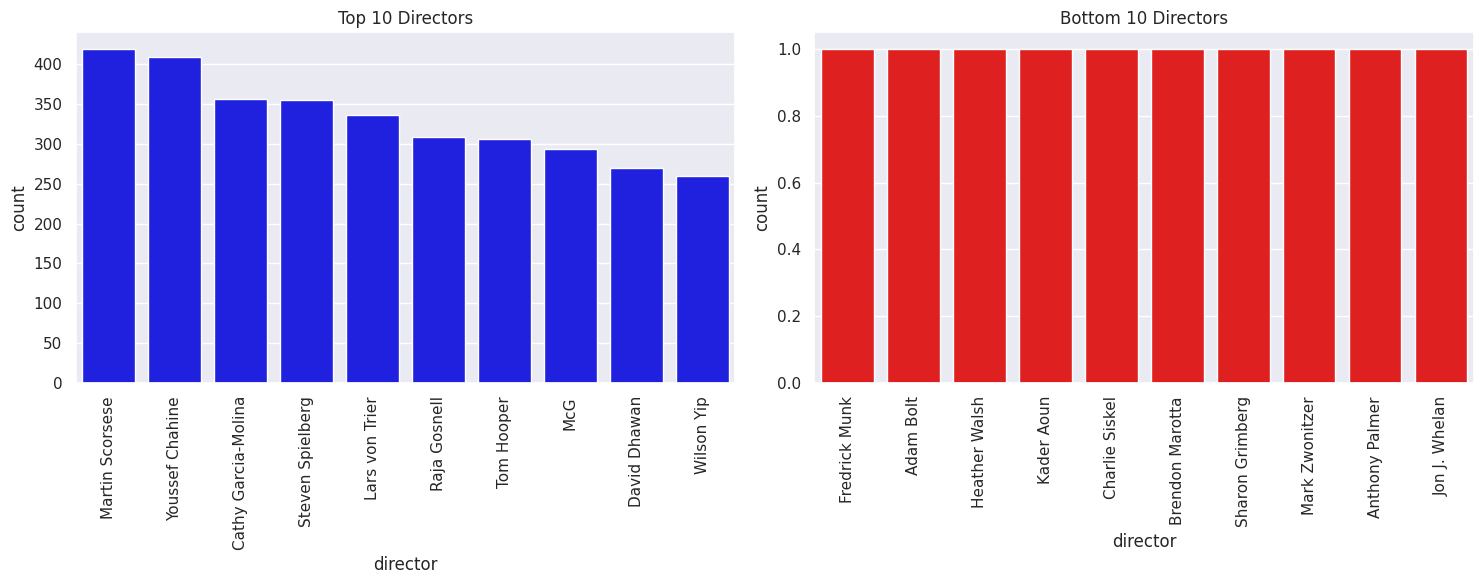

In [98]:
# Graphical Analysis (Omitting Unknown Director)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Getting top 10 directors
top10_directors = df_final["director"].value_counts().index[1:11]
top10_director_netflix = df_final.loc[df_final["director"].isin(top10_directors)]

# Getting bottom 10 directors
bottom10_directors = df_final["director"].value_counts().index[-11:-1]
bottom10_director_netflix = df_final.loc[df_final["director"].isin(bottom10_directors)]

# Plotting top 10 directors
sns.countplot(x='director', data=top10_director_netflix, order=top10_director_netflix['director'].value_counts().index, color='blue', ax=axes[0])
axes[0].set_title('Top 10 Directors')
plt.sca(axes[0])  # Set the current axes to the first subplot
plt.xticks(rotation=90)  # Rotate x-axis labels

# Plotting bottom 10 directors
sns.countplot(x='director', data=bottom10_director_netflix, order=bottom10_director_netflix['director'].value_counts().index, color='red', ax=axes[1])
axes[1].set_title('Bottom 10 Directors')
plt.sca(axes[1])  # Set the current axes to the second subplot
plt.xticks(rotation=90)  # Rotate x-axis labels

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()




In [99]:
df_final["director"].value_counts()[1:11]

director
Martin Scorsese        419
Youssef Chahine        409
Cathy Garcia-Molina    356
Steven Spielberg       355
Lars von Trier         336
Raja Gosnell           308
Tom Hooper             306
McG                    293
David Dhawan           270
Wilson Yip             260
Name: count, dtype: int64

## **Observation :**

1.  The **Top 10 directors** are shown on the LHS graph:

    **Highest : Martin Scorsese** - 419 counts
    **10th highest :Wilson Yip** -260 counts  

2.  The **Bottom 10 directors** are shown on the RHS graph:

    All of them seem to have **only 1 movie/tv_show** under their belt



## **EDA.4.Analysis of actors/directors of different types of shows/movies**

**For Movies**

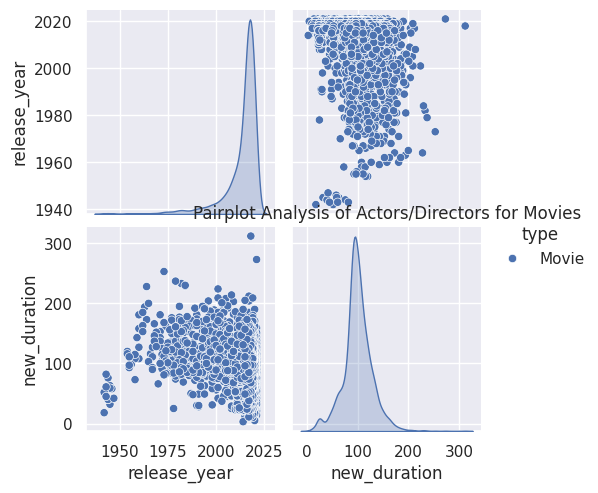

In [100]:
# Filter data for movies
df_movies = no_repeat_df_final[no_repeat_df_final['type'] == 'Movie'][['director', 'cast', 'type', 'release_year', 'new_duration', 'rating']]

# Pairplot for movies
sns.pairplot(df_movies, hue='type')
plt.title('Pairplot Analysis of Actors/Directors for Movies')
plt.show()


**For TV Shows:**

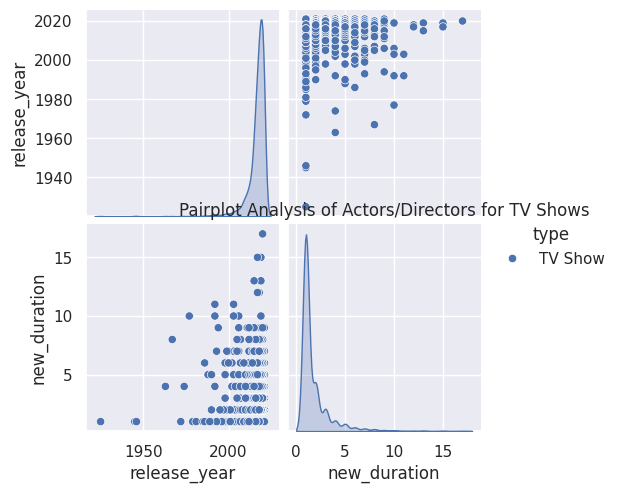

In [101]:
# Filter data for TV shows
df_tv_shows = no_repeat_df_final[no_repeat_df_final['type'] == 'TV Show'][['director', 'cast', 'type', 'release_year', 'new_duration', 'rating']]

# Pairplot for TV shows
sns.pairplot(df_tv_shows, hue='type')
plt.title('Pairplot Analysis of Actors/Directors for TV Shows')
plt.show()


## **Observations:**
**Pairplot Analysis of actors/directors of different types of shows/movies.**

**Attributes:** release_year and new_duration

**Distribution Insights:**
**Release Year:** Most movies in the dataset are released post-1980, with a peak around the 2000s.
**New Duration:** Movie durations cluster around a median duration, with few movies exceeding 200 minutes.

**Scatter Plot Insights:**
**Release Year vs. Duration:** There is no clear pattern or trend between the release year of movies and their durations.

The scatter plot indicates a wide spread across different release years and durations, supporting the low correlation observed in the heatmap.

### **3.Column 'cast' :**
Finding the Top 10 , Bottom 10 actor/actress

In [102]:
# Non Graphical Analysis
df_final["cast"].value_counts()[1:11]

cast
Liam Neeson         161
Alfred Molina       160
John Krasinski      139
Salma Hayek         130
Frank Langella      128
Anupam Kher         127
John Rhys-Davies    125
Shah Rukh Khan      108
Naseeruddin Shah    106
Radhika Apte        104
Name: count, dtype: int64

In [103]:
df_final["cast"].nunique()

36440

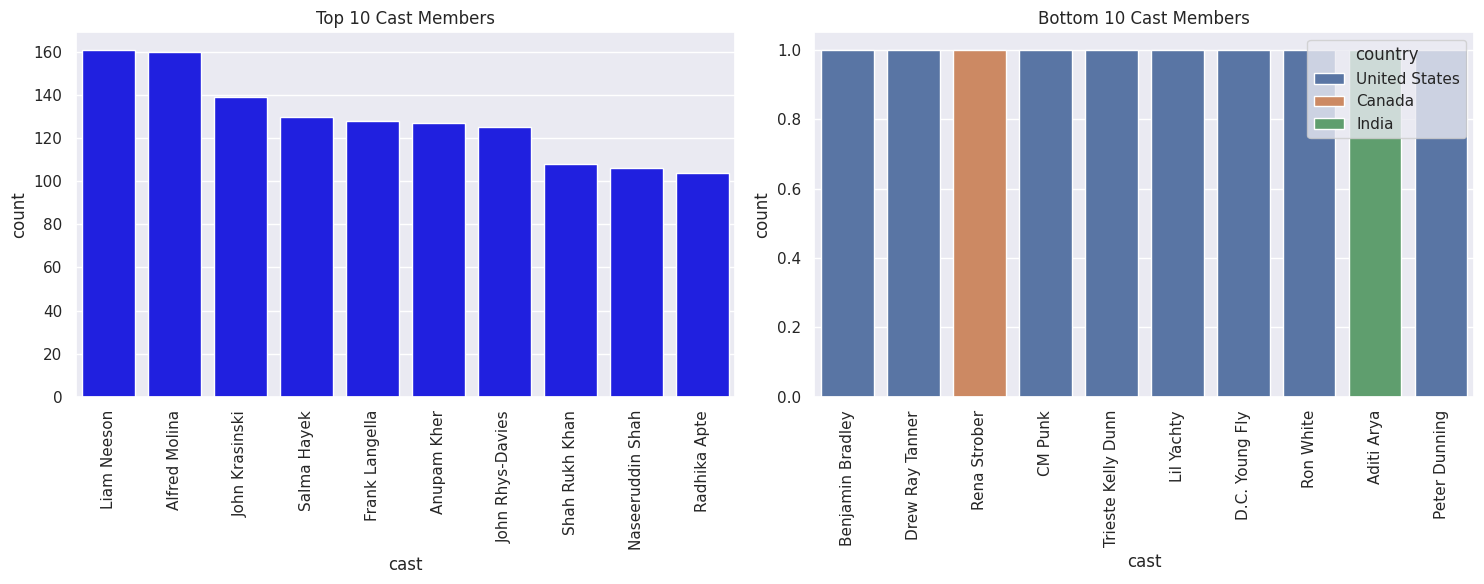

In [104]:
# Graphical Analysis (Omitting Unknown Actor)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Getting top 10 cast members
top10_cast = df_final["cast"].value_counts().index[1:11]
top10_cast_netflix = df_final.loc[df_final["cast"].isin(top10_cast)]

# Getting bottom 10 cast members
bottom10_cast = df_final["cast"].value_counts().index[-11:-1]
bottom10_cast_netflix = df_final.loc[df_final["cast"].isin(bottom10_cast)]

# Plotting top 10 cast members
sns.countplot(x='cast',data=top10_cast_netflix, order=top10_cast_netflix['cast'].value_counts().index, color='blue', ax=axes[0])


axes[0].set_title('Top 10 Cast Members')
plt.sca(axes[0])  # Set the current axes to the first subplot
plt.xticks(rotation=90)  # Rotate x-axis labels

# Plotting bottom 10 cast members
#sns.countplot(x='cast', data=bottom10_cast_netflix, order=bottom10_cast_netflix['cast'].value_counts().index, color='red', ax=axes[1])
sns.countplot(x='cast', hue='country', data=bottom10_cast_netflix, order=bottom10_cast_netflix['cast'].value_counts().index, ax=axes[1])

axes[1].set_title('Bottom 10 Cast Members')
plt.sca(axes[1])  # Set the current axes to the second subplot
plt.xticks(rotation=90)  # Rotate x-axis labels

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


## **Observation :**

1.  The **Top 10 actor/actress** are shown on the LHS graph:

    **Highest : Liam Leeson,Alfred Molina** - 161,160 counts

    **10th highest :Radhika Apte** -104 counts ( Remarkable rise within short period of time)

2.  The **Bottom 10 actor/actress** are shown on the RHS graph:

    All of them seem to have **only 1 movie/tv_show** under their belt

# **EDA.6.Understanding what content is available in different countries**

### **4.Column 'country' :**
Finding the Top 10 , Bottom 10 countries 🇰
Due to un-nesting multiple entries for the same title occur and to avoid counting the same entry twice or more , creating  separate datframe .

In [105]:
# Removing duplicates based on 'title' and 'show_id'
no_repeat_df_final =  df_final.drop_duplicates(subset=['title', 'show_id'], keep='first')
no_repeat_df_final.head(3)

,title,director,cast,show_id,type,country,date_added,release_year,rating,duration,genre,description,new_duration,date_when_added,year_added,month_added,month_name_added,week_added
0,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,s1,Movie,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,2021-09-25,2021,9,Sep,38
1,Blood & Water,Unknown Director,Ama Qamata,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2,2021-09-24,2021,9,Sep,38
58,Ganglands,Julien Leclercq,Sami Bouajila,s3,TV Show,France,"September 24, 2021",2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,1,2021-09-24,2021,9,Sep,38


In [106]:
# Non Graphical Analysis
no_repeat_df_final["country"].value_counts()

country
United States     3911
India             1073
United Kingdom     633
Canada             274
Japan              267
                  ... 
Namibia              1
Senegal              1
Luxembourg           1
Syria                1
Somalia              1
Name: count, Length: 86, dtype: int64

In [107]:
no_repeat_df_final["country"].nunique()

86

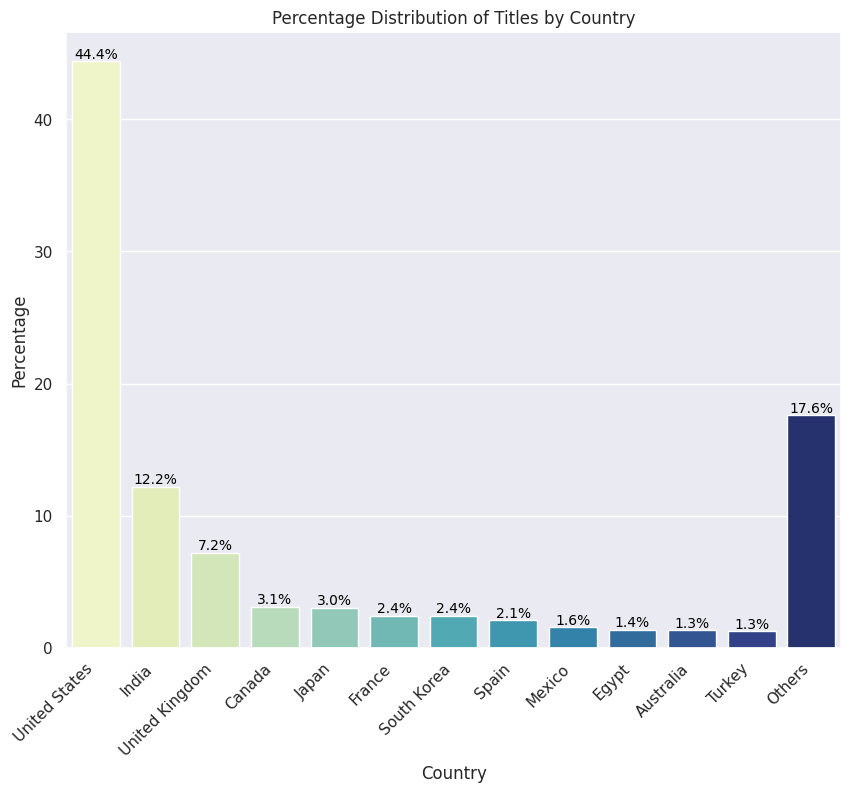

In [108]:
# Number of titles available per country
content_per_country = no_repeat_df_final['country'].value_counts().reset_index(name='count')
content_per_country.columns = ['country', 'count']

# Select top 12 countries and group the rest as "Others"
top_countries = content_per_country.head(12).copy()
other_count = content_per_country['count'][12:].sum()
top_countries.loc[len(top_countries)] = ['Others', other_count]

# Calculate percentages
total_titles = top_countries['count'].sum()
top_countries['percentage'] = (top_countries['count'] / total_titles) * 100

# Bar plot
plt.figure(figsize=(10, 8))
ax = sns.barplot(x='country', y='percentage', data=top_countries, hue='country', palette='YlGnBu', dodge=False, legend=False)
plt.xlabel('Country')
plt.ylabel('Percentage')
plt.title('Percentage Distribution of Titles by Country')
plt.xticks(rotation=45, ha='right')

# Add percentage labels on top of each bar using the annotate parameter
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points', annotation_clip=False)

plt.show()


## **Observations:**
**Understanding what content is available in different countries**

* The majority of content around-50% is from US and India ( someof it from UK). Other countries together contribute to the rest 50% . This shows the large followership of US , Indian content .

* However for better diversity and inclusitivity, contents needs to come from rest of the world.

**Top 10,Bottom 10**

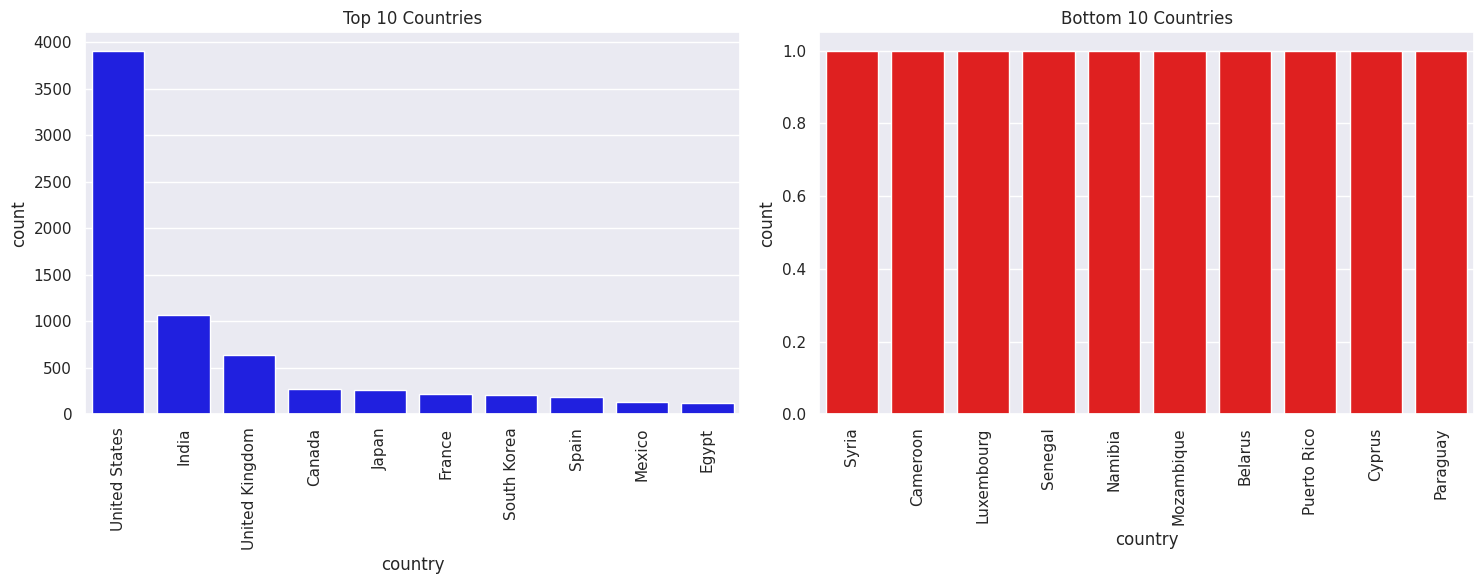

In [109]:
# Graphical Analysis

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Getting top 10 countries
top10_countries = no_repeat_df_final["country"].value_counts().index[0:10]
top10_countries_netflix = no_repeat_df_final.loc[no_repeat_df_final["country"].isin(top10_countries)]

# Getting bottom 10 countries
bottom10_countries = no_repeat_df_final["country"].value_counts().index[-11:-1]
bottom10_countries_netflix = no_repeat_df_final.loc[no_repeat_df_final["country"].isin(bottom10_countries)]

# Plotting top 10 countries
sns.countplot(x='country', data=top10_countries_netflix, order=top10_countries_netflix['country'].value_counts().index, color='blue', ax=axes[0])
axes[0].set_title('Top 10 Countries')
plt.sca(axes[0])  # Set the current axes to the first subplot
plt.xticks(rotation=90)  # Rotate x-axis labels

# Plotting bottom 10 countries
sns.countplot(x='country', data=bottom10_countries_netflix, order=bottom10_countries_netflix['country'].value_counts().index, color='red', ax=axes[1])
axes[1].set_title('Bottom 10 Countries')
plt.sca(axes[1])  # Set the current axes to the second subplot
plt.xticks(rotation=90)  # Rotate x-axis labels

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()



In [110]:
no_repeat_df_final["country"].value_counts()[0:10]
#no_repeat_df_final["country"].value_counts()[-11:-1]

country
United States     3911
India             1073
United Kingdom     633
Canada             274
Japan              267
France             215
South Korea        213
Spain              183
Mexico             138
Egypt              120
Name: count, dtype: int64

In [111]:

# Step 1: Calculate the value counts of the 'country' column
country_counts = no_repeat_df_final["country"].value_counts()

# Step 2: Identify the countries that appear exactly once
single_occurrence_countries = country_counts[country_counts == 1].sum()
single_occurrence_countries

19

## **Observation :**

1.  The **Top 10 countries contributing to movies/tv shows** are shown on the LHS graph:

    **Highest : United States**     3923 counts

    **10th highest :Egypt**            120 counts
    

2.  The **Bottom 10 countries contributing to movies/tv shows** are shown on the RHS graph:

    There are **total 19 countries**  with **only 1 movie/tv_show** under their belt . We have shown the last 10

--------------------------------------------------------------------------------

# **5.Column 'year_added' :**

This is a self created column from 'date_added' column . To avoid duplicate entries using **no_repeat_df_final** dataframe .Since Year is categorical column ,finding top 5 and bottom 5 entries

In [112]:
# Non Graphical Analysis
no_repeat_df_final["year_added"].value_counts()

year_added
2019    2016
2020    1889
2018    1649
2021    1498
2017    1188
2016     429
2015      82
2014      24
2011      13
2013      11
2012       3
2009       2
2008       2
2010       1
Name: count, dtype: int64

In [113]:
no_repeat_df_final["year_added"].nunique()

14

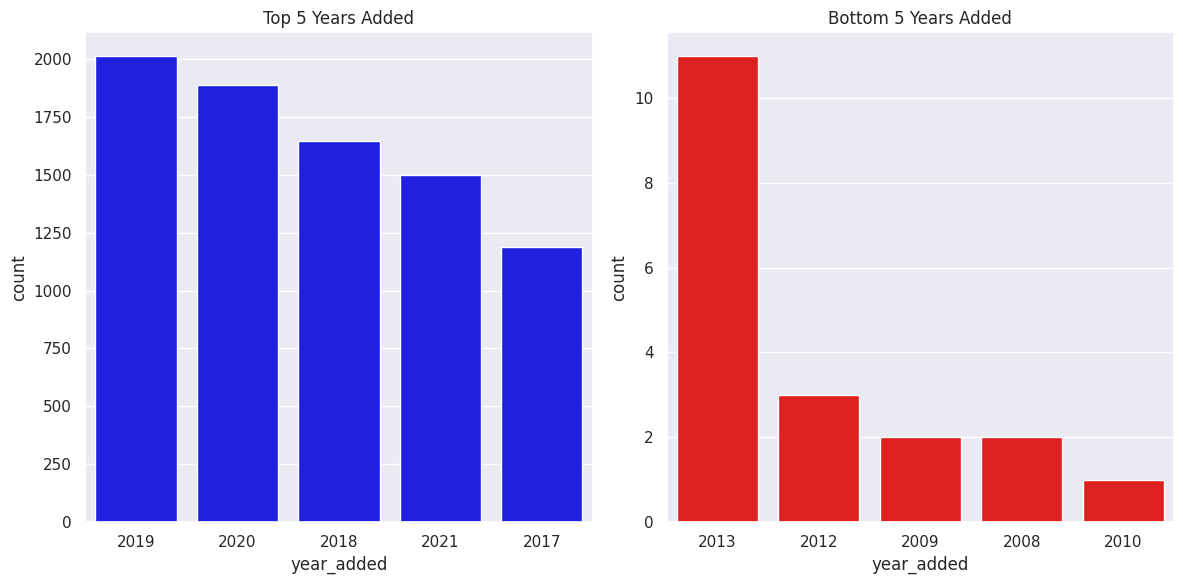

In [114]:
# Graphical Analysis

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Getting top 5 years added
top5_years_added = no_repeat_df_final["year_added"].value_counts().index[:5]
top5_years_netflix = no_repeat_df_final.loc[no_repeat_df_final["year_added"].isin(top5_years_added)]

# Getting bottom 5 years added
bottom5_years_added = no_repeat_df_final["year_added"].value_counts().index[-5:]
bottom5_years_netflix = no_repeat_df_final.loc[no_repeat_df_final["year_added"].isin(bottom5_years_added)]

# Plotting top 5 years added
sns.countplot(x='year_added', data=top5_years_netflix, order=top5_years_netflix['year_added'].value_counts().index, color='blue', ax=axes[0])
axes[0].set_title('Top 5 Years Added')
plt.sca(axes[0])  # Set the current axes to the first subplot
#plt.xticks(rotation=90)  # Rotate x-axis labels

# Plotting bottom 5 years added
sns.countplot(x='year_added', data=bottom5_years_netflix, order=bottom5_years_netflix['year_added'].value_counts().index, color='red', ax=axes[1])
axes[1].set_title('Bottom 5 Years Added')
plt.sca(axes[1])  # Set the current axes to the second subplot
#plt.xticks(rotation=90)  # Rotate x-axis labels

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


In [115]:
no_repeat_df_final["year_added"].value_counts()[0:5]
#no_repeat_df_final["year_added"].value_counts()[-5:].sum()


year_added
2019    2016
2020    1889
2018    1649
2021    1498
2017    1188
Name: count, dtype: int64

## **Observation :**

1.  The **Top 5 year when movies/tv shows added to the platform** are shown on the LHS graph:

    **Highest : 2019** --    2016 counts

    **5th highest :2017**    1188 counts
    

2.  The **Bottom 5 year when movies/tv shows added to the platform** are shown on the RHS graph:

   ** Between 2013 and 2010 only 19 new movies/tv_shows** added to the platform where 13 were added in 2013 and only 1 in 2010

--------------------------------------------------------------------------------

## **EDA.2.What is the best time to launch a TV show?**

# **6.Column 'month_name_added' :**

This is a self created column from 'date_added' column . To avoid duplicate entries using **no_repeat_df_final** dataframe .

In [116]:
# Non Graphical Analysis
no_repeat_df_final["month_name_added"].value_counts()

month_name_added
Jul    827
Dec    813
Sep    770
Apr    764
Oct    760
Aug    755
Jan    748
Mar    742
Jun    728
Nov    705
May    632
Feb    563
Name: count, dtype: int64

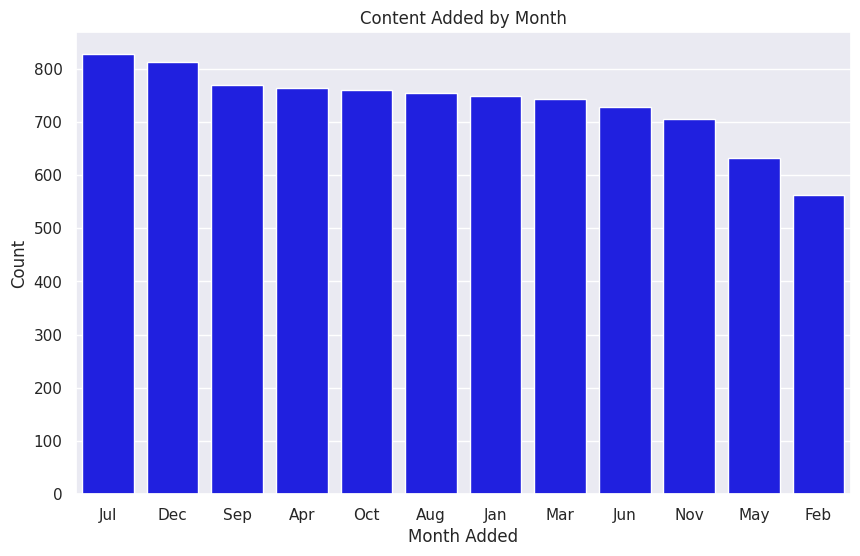

In [117]:
# Graphical Analysis

plt.figure(figsize=(10,6))
sns.countplot(x='month_name_added', data=no_repeat_df_final,
              order= no_repeat_df_final["month_name_added"].value_counts().index,
              color='blue')
plt.title('Content Added by Month')
plt.xlabel('Month Added')
plt.ylabel('Count')
plt.show()

## **Observation :**

1.  The **Top months** when maximum number of movies/tv_shows were added to the platform are

1.  **July :** 827 counts
2.   **Dec:** 813 counts
3.   **The least were added during Feb**

Platforms/Studios often release their movies in packed blockbuster months, such as the summer and holiday seasons, for a few reasons.

First, these months tend to have higher audience attendance, as people have more leisure time and are often in a more relaxed and receptive mood.

Second, these periods are associated with **major holidays and vacations**, which can lead to increased box office sales.
  
Additionally, releasing a movie during a blockbuster month can provide it with greater visibility and competition with other high-profile releases, potentially leading to more buzz and attention.

**Overall, the goal is to maximize the movie's exposure and potential for success.**

## **Segregating data by Movie and TV Shows**

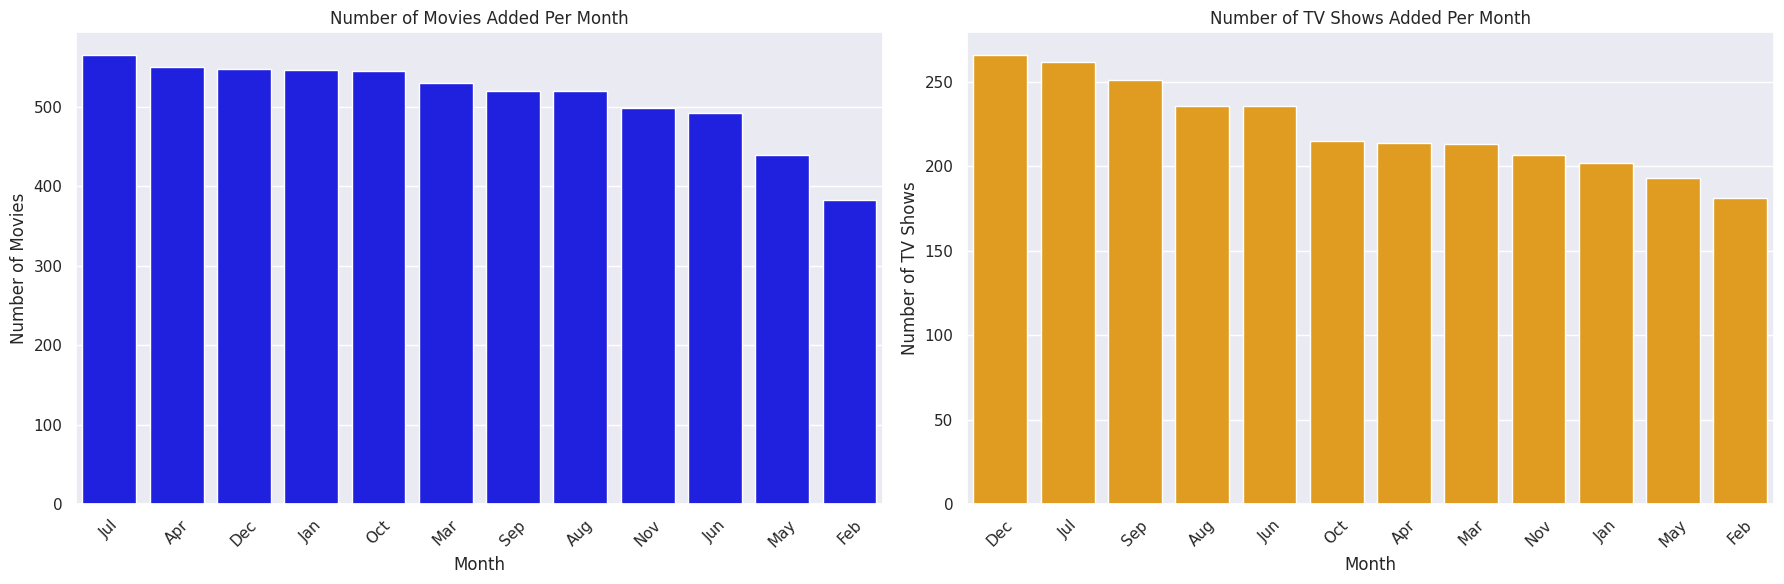

In [118]:

# Number of TV shows added per month
tv_shows_per_month = no_repeat_df_final[no_repeat_df_final['type'] == 'TV Show']['month_name_added'].value_counts()

# Number of movies added per month
movies_per_month = no_repeat_df_final[no_repeat_df_final['type'] == 'Movie']['month_name_added'].value_counts()

# Plotting the results in subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# Plot for Movies
sns.barplot(x=movies_per_month.index, y=movies_per_month.values, ax=axes[0], color='blue')
axes[0].set_title('Number of Movies Added Per Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Movies')
axes[0].tick_params(axis='x', rotation=45)


# Plot for TV shows
sns.barplot(x=tv_shows_per_month.index, y=tv_shows_per_month.values, ax=axes[1], color='orange')
axes[1].set_title('Number of TV Shows Added Per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of TV Shows')
axes[1].tick_params(axis='x', rotation=45)



plt.tight_layout()
plt.show()



## **Observations:**

**What is the best time to launch a Movie or a TV show?**

*   July ,April, December months seem to be the best months for launching Movies (in that order)
*    December and July seem to be best for TV Shows (in that order)




--------------------------------------------------------------------------------

# **EDA.3.How has the number of movies released per year changed over the last 20-30 years?**

# **7.Column 'release_year' :**
Top 10 and Bottom 10 years when movies were released.

To avoid duplicate entries using **no_repeat_df_final** dataframe .

In [119]:
# Non Graphical Analysis
no_repeat_df_final["release_year"].value_counts()

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
        ... 
1959       1
1925       1
1961       1
1947       1
1966       1
Name: count, Length: 74, dtype: int64

In [120]:
no_repeat_df_final["release_year"].nunique()

74

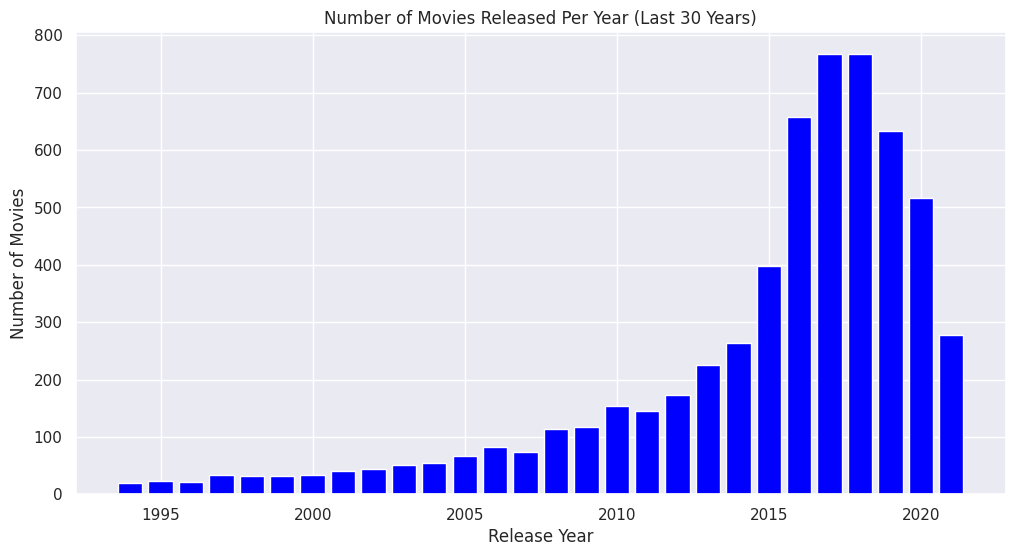

In [121]:
# Filter the data for movies only and for the last 30 years
current_year = 2024
start_year = current_year - 30

filtered_df = no_repeat_df_final[(no_repeat_df_final['type'] == 'Movie') & (no_repeat_df_final['release_year'] >= start_year)]

# Group by release year and count the number of movies
movies_per_year = filtered_df.groupby('release_year').size().reset_index(name='count')

# Plotting the results
plt.figure(figsize=(12, 6))
plt.bar(movies_per_year['release_year'], movies_per_year['count'], color='blue')
plt.title('Number of Movies Released Per Year (Last 30 Years)')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.xticks()
plt.show()

## **Observations:**
**How has the number of movies released per year changed over the last 20-30 years?**

The number of Movies started increasing from 2015 , peaked in 2017-2018 and  decreased after 2018 .

A sharp decrease seen in 2021 maybe due to Covid Pandemic because of which Film and TV industry was brought to a halt.


## **Finding Top 10 , Bottom 10 Release Years**

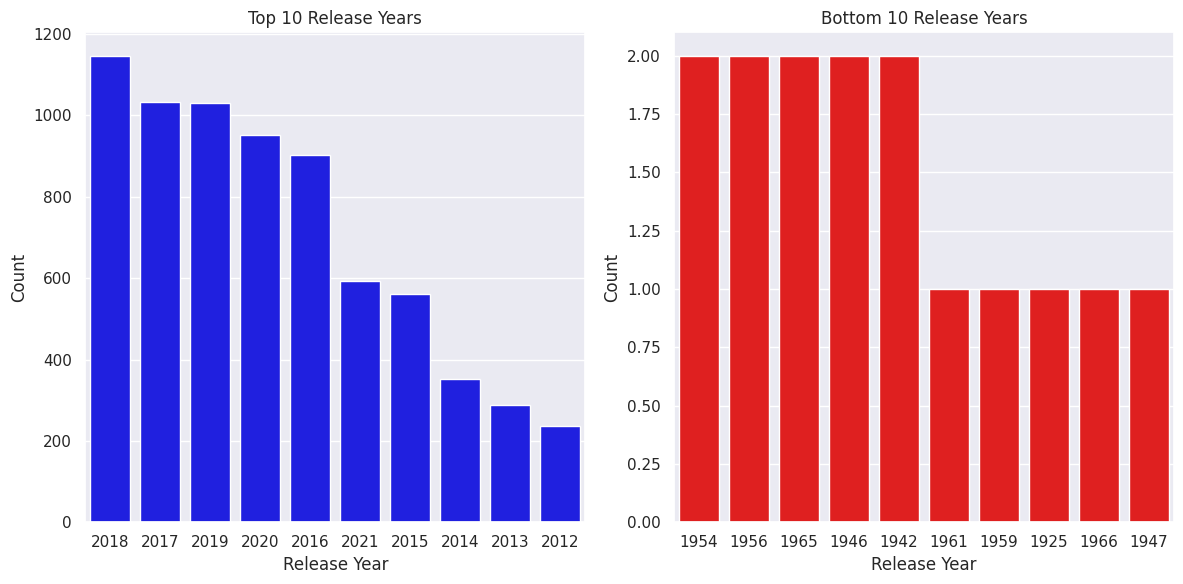

In [122]:
# Graphical Analysis

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Getting top 10 release years
top10_release_years = no_repeat_df_final["release_year"].value_counts().index[:10]
top10_years_movies = no_repeat_df_final.loc[no_repeat_df_final["release_year"].isin(top10_release_years)]

# Getting bottom 10 release years
bottom10_release_years = no_repeat_df_final["release_year"].value_counts().index[-10:]
bottom10_years_movies = no_repeat_df_final.loc[no_repeat_df_final["release_year"].isin(bottom10_release_years)]

# Plotting top 10 release years
sns.countplot(x='release_year', data=top10_years_movies, order=top10_years_movies['release_year'].value_counts().index, color='blue', ax=axes[0])
axes[0].set_title('Top 10 Release Years')
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Count')
plt.sca(axes[0])  # Set the current axes to the first subplot
#plt.xticks(rotation=90)  # Rotate x-axis labels if needed

# Plotting bottom 10 release years
sns.countplot(x='release_year', data=bottom10_years_movies, order=bottom10_years_movies['release_year'].value_counts().index, color='red', ax=axes[1])
axes[1].set_title('Bottom 10 Release Years')
axes[1].set_xlabel('Release Year')
axes[1].set_ylabel('Count')
plt.sca(axes[1])  # Set the current axes to the second subplot
#plt.xticks(rotation=90)  # Rotate x-axis labels if needed

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [123]:
no_repeat_df_final["release_year"].value_counts()[0:10]
no_repeat_df_final["release_year"].value_counts()[-11:-1]

release_year
1963    2
1956    2
1965    2
1946    2
1942    2
1954    2
1959    1
1925    1
1961    1
1947    1
Name: count, dtype: int64

## **Observations :**

1.  The **Top 10 years when maximum releases happened** are shown on the LHS graph:

    **Highest : 2018**    1147 counts

    **10th highest :2012**     237 counts

    It can be seen the nummber of releases have become 5 times since 2012
    

2.  The **Bottom 10 years when maximum releases happened**** are shown on the RHS graph:

   Years 1963,1956,1965,1946,1942 saw only 2 releases , with years 1959,1925,1961,1947  saw only 1 release
    
    
   
    
    
    
    

# **EDA.5.Does Netflix has more focus on TV Shows than movies in recent years**

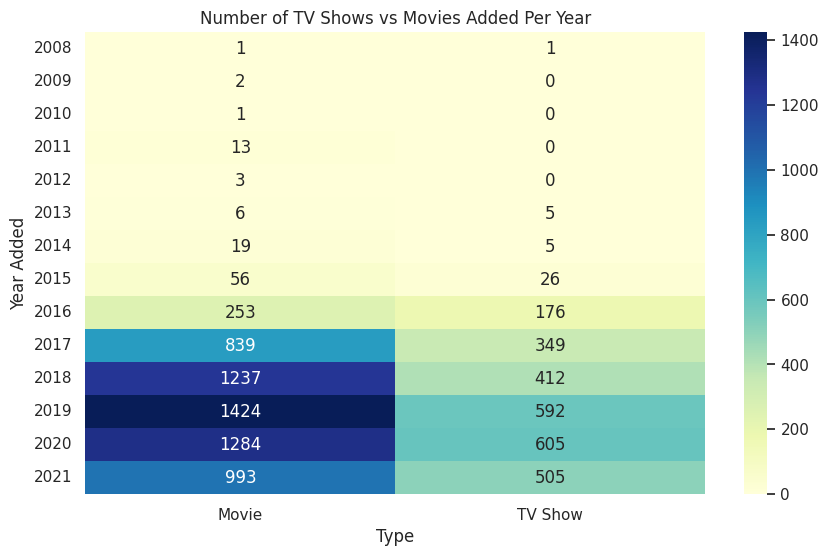

In [124]:
# Number of TV shows and movies added per year
content_per_year = no_repeat_df_final.groupby(['year_added', 'type']).size().unstack().fillna(0)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(content_per_year, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Number of TV Shows vs Movies Added Per Year')
plt.xlabel('Type')
plt.ylabel('Year Added')
plt.show()



## **Observations:**

**Does Netflix has more focus on TV Shows than movies in recent years?**

#### **Insights:**

1. **Growth Trend in Content Addition**:
   - There has been a significant increase in the number of both movies and TV shows added to Netflix from 2016 onward.
   - The number of movies added per year peaked in 2019 with 1424 movies, while the number of TV shows added has shown a steady increase each year, peaking at 605 in 2020.

2. **Comparative Analysis of Movies vs. TV Shows**:
   - From 2016 to 2021, Netflix added more movies than TV shows every year.
   - The gap between the number of movies and TV shows added has been narrowing. For example, in 2017, 839 movies were added compared to 349 TV shows, whereas in 2020, the numbers were 1284 movies and 605 TV shows, showing a relative increase in TV shows.

3. **Recent Focus (2019-2021)**:
   - While the total number of movies added in recent years (2019-2021) remains higher than TV shows, the increase in TV shows is notable.
   - The number of TV shows added in 2020 (605) surpassed the number added in 2019 (592), indicating a growing focus on TV shows.

4. **Content Strategy Shift**:
   - Netflix's strategy appears to be diversifying, with significant investments in both movies and TV shows.
   - The substantial increase in TV show additions suggests a shift towards balancing their content portfolio, possibly to cater to changing viewer preferences for binge-watching TV series.

#### **Recommendations:**

1. **Balanced Content Strategy**:
   - Continue to invest in both movies and TV shows to cater to a broad audience. This balanced approach can help attract and retain different viewer segments.

2. **Data-Driven Content Decisions**:
   - Utilize viewer data to identify which genres and formats (movies vs. TV shows) are most popular among subscribers. This can help in making informed decisions about future content acquisitions and productions.

3. **Original Content Development**:
   - Invest in high-quality original TV shows and movies to differentiate Netflix from competitors. Originals often drive subscriptions and can lead to long-term viewer loyalty.

4. **Global Content Expansion**:
   - Expand the library with international TV shows and movies to attract a global audience. This can also help in tapping into emerging markets with diverse content preferences.

5. **Marketing and Promotion**:
   - Promote TV shows and movies effectively, emphasizing unique and exclusive content to attract new subscribers and retain existing ones. Highlighting critically acclaimed and popular content can also boost viewership.





**----------------------------------------------------------------------------------------------------------------------------------------------------------------**

# **8.Column 'rating' :**

Analysing top5 and bottom 5 ratings
To avoid duplicate entries using **no_repeat_df_final** dataframe .

--------------------------------------------------------------------------------

In [125]:
# Non Graphical Analysis
no_repeat_df_final["rating"].value_counts()

rating
TV-MA                   3210
TV-14                   2160
TV-PG                    863
R                        799
PG-13                    490
TV-Y7                    334
TV-Y                     307
PG                       287
TV-G                     220
NR                        80
G                         41
TV-Y7-FV                   6
Rating Not Available       4
NC-17                      3
UR                         3
Name: count, dtype: int64

In [126]:
no_repeat_df_final["rating"].nunique()

15

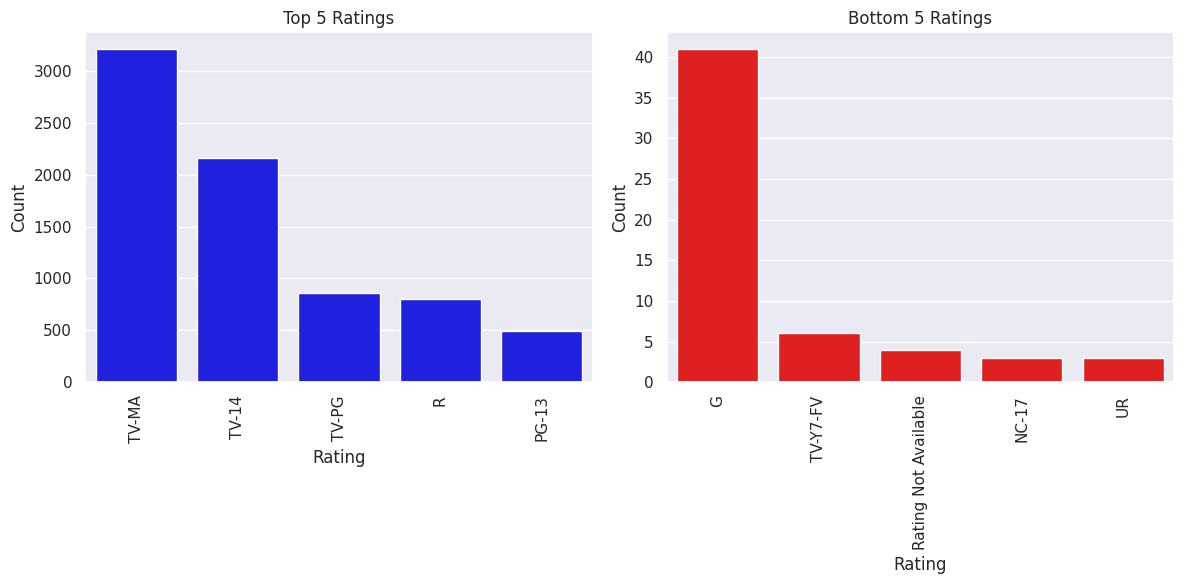

In [127]:
# Graphical Analysis

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Getting top 5 ratings
top5_ratings = no_repeat_df_final["rating"].value_counts().index[:5]
top5_ratings_movies = no_repeat_df_final.loc[no_repeat_df_final["rating"].isin(top5_ratings)]

# Getting bottom 5 ratings
bottom5_ratings = no_repeat_df_final["rating"].value_counts().index[-5:]
bottom5_ratings_movies = no_repeat_df_final.loc[no_repeat_df_final["rating"].isin(bottom5_ratings)]

# Plotting top 5 ratings
sns.countplot(x='rating', data=top5_ratings_movies, order=top5_ratings_movies['rating'].value_counts().index, color='blue', ax=axes[0])
axes[0].set_title('Top 5 Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
plt.sca(axes[0])  # Set the current axes to the first subplot
plt.xticks(rotation=90)  # Rotate x-axis labels if needed

# Plotting bottom 5 ratings
sns.countplot(x='rating', data=bottom5_ratings_movies, order=bottom5_ratings_movies['rating'].value_counts().index, color='red', ax=axes[1])
axes[1].set_title('Bottom 5 Ratings')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
plt.sca(axes[1])  # Set the current axes to the second subplot
plt.xticks(rotation=90)  # Rotate x-axis labels if needed

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


In [128]:
no_repeat_df_final["rating"].value_counts()[0:5]
no_repeat_df_final["rating"].value_counts()[-5:]

rating
G                       41
TV-Y7-FV                 6
Rating Not Available     4
NC-17                    3
UR                       3
Name: count, dtype: int64

## **Observation :**

1.  The **Top 5 ratings** are shown on the LHS graph:

    **Highest : TV-MA**    3210 counts

    **5th highest :PG-13**     490 counts

    Ranging from Adult content -  material inappropriate for children under 13 seem to be dominating the platform
    

2.  The **Bottom 5 ratings** are shown on the RHS graph:

   Ratings - NC-17 , UR  seem to be the least favourite with just 3 counts each                
                      

### **Segregating Top, Bottom 5 ratings for Movies and TV Shows:**


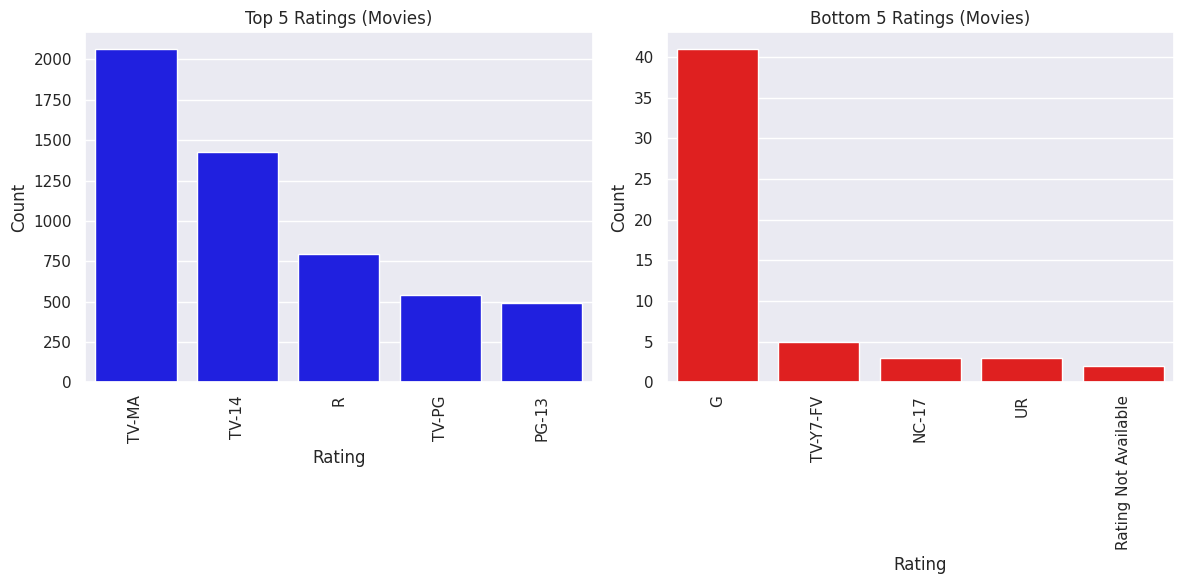

In [129]:
# Top , Bottom 5 ratings for Movies


# Filter data for movies
movies_df = no_repeat_df_final[no_repeat_df_final['type'] == 'Movie']

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Getting top 5 ratings for movies
top5_ratings_movies = movies_df["rating"].value_counts().index[:5]
top5_ratings_movies_data = movies_df[movies_df["rating"].isin(top5_ratings_movies)]

# Getting bottom 5 ratings for movies
bottom5_ratings_movies = movies_df["rating"].value_counts().index[-5:]
bottom5_ratings_movies_data = movies_df[movies_df["rating"].isin(bottom5_ratings_movies)]

# Plotting top 5 ratings for movies
sns.countplot(x='rating', data=top5_ratings_movies_data, order=top5_ratings_movies_data['rating'].value_counts().index, color='blue', ax=axes[0])
axes[0].set_title('Top 5 Ratings (Movies)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
plt.sca(axes[0])  # Set the current axes to the first subplot
plt.xticks(rotation=90)  # Rotate x-axis labels if needed

# Plotting bottom 5 ratings for movies
sns.countplot(x='rating', data=bottom5_ratings_movies_data, order=bottom5_ratings_movies_data['rating'].value_counts().index, color='red', ax=axes[1])
axes[1].set_title('Bottom 5 Ratings (Movies)')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
plt.sca(axes[1])  # Set the current axes to the second subplot
plt.xticks(rotation=90)  # Rotate x-axis labels if needed

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


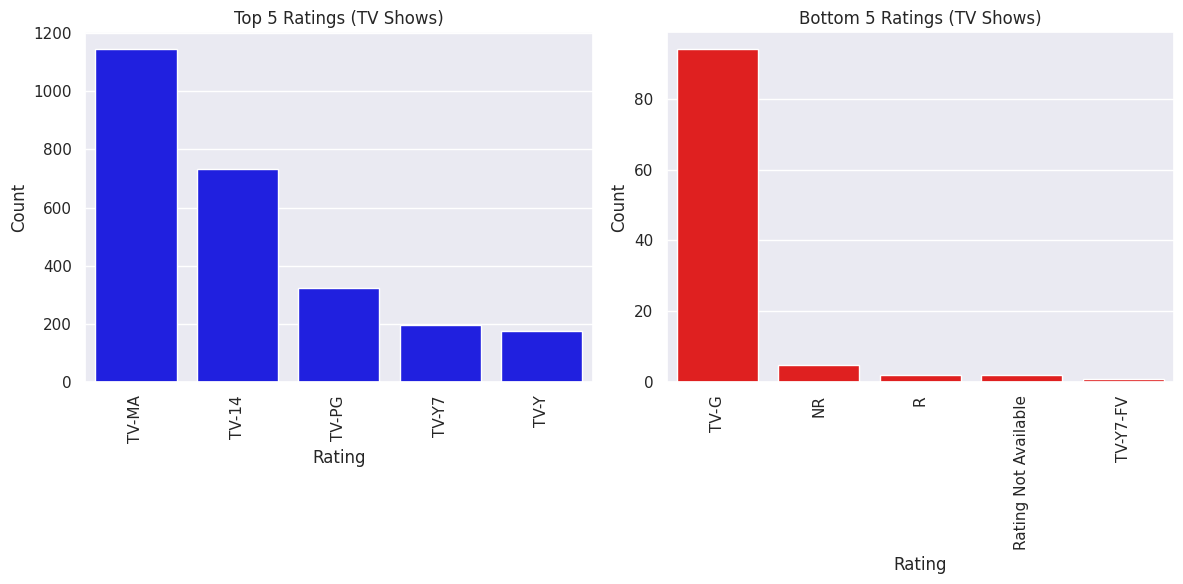

In [130]:
# Top5 ,Bottom 5 ratings for TV Shows

# Filter data for TV shows
tvshows_df = no_repeat_df_final[no_repeat_df_final['type'] == 'TV Show']

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Getting top 5 ratings for TV shows
top5_ratings_tvshows = tvshows_df["rating"].value_counts().index[:5]
top5_ratings_tvshows_data = tvshows_df[tvshows_df["rating"].isin(top5_ratings_tvshows)]

# Getting bottom 5 ratings for TV shows
bottom5_ratings_tvshows = tvshows_df["rating"].value_counts().index[-5:]
bottom5_ratings_tvshows_data = tvshows_df[tvshows_df["rating"].isin(bottom5_ratings_tvshows)]

# Plotting top 5 ratings for TV shows
sns.countplot(x='rating', data=top5_ratings_tvshows_data, order=top5_ratings_tvshows_data['rating'].value_counts().index, color='blue', ax=axes[0])
axes[0].set_title('Top 5 Ratings (TV Shows)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
plt.sca(axes[0])  # Set the current axes to the first subplot
plt.xticks(rotation=90)  # Rotate x-axis labels if needed

# Plotting bottom 5 ratings for TV shows
sns.countplot(x='rating', data=bottom5_ratings_tvshows_data, order=bottom5_ratings_tvshows_data['rating'].value_counts().index, color='red', ax=axes[1])
axes[1].set_title('Bottom 5 Ratings (TV Shows)')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
plt.sca(axes[1])  # Set the current axes to the second subplot
plt.xticks(rotation=90)  # Rotate x-axis labels if needed

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


--------------------------------------------------------------------------------

# **9.Column 'new_duration' :**

As its a numerical column, calulating mean will help analysing the data

In [131]:
# Non Graphical Analysis
no_repeat_df_final["duration"].value_counts()

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
             ... 
16 min          1
186 min         1
193 min         1
189 min         1
191 min         1
Name: count, Length: 220, dtype: int64

In [132]:
no_repeat_df_final["duration"].nunique()

220

In [133]:
df["type"].unique()

array(['Movie', 'TV Show'], dtype=object)

In [134]:
# Separate data for movies and TV shows

movies_data = no_repeat_df_final[no_repeat_df_final['type'] == 'Movie']
tv_shows_data = no_repeat_df_final[no_repeat_df_final['type'] == 'TV Show']

# Descriptive statistics for movies
movies_description = movies_data.describe()

# Descriptive statistics for TV shows
tv_shows_description = tv_shows_data.describe()



In [135]:
# Print descriptions
print("Summary statistics for movies:")
movies_description

Summary statistics for movies:


,release_year,new_duration,date_when_added,year_added,month_added,week_added
count,6131.000000,6131.000000,6131,6131.000000,6131.000000,6131.0
mean,2013.121514,99.564998,2019-05-07 03:32:47.639863040,2018.849290,6.608057,26.217746
min,1942.000000,3.000000,2008-01-01 00:00:00,2008.000000,1.000000,1.0
25%,2012.000000,87.000000,2018-04-01 00:00:00,2018.000000,4.000000,13.0
50%,2016.000000,98.000000,2019-06-19 00:00:00,2019.000000,7.000000,26.0
75%,2018.000000,114.000000,2020-07-23 12:00:00,2020.000000,10.000000,39.0
max,2021.000000,312.000000,2021-09-25 00:00:00,2021.000000,12.000000,53.0
std,9.678169,28.289504,NaN,1.561922,3.452525,15.116396


## **Observations:**

**Some Insights from the Description Table for Movies**

* Overall, the distribution shows that most movies are around 99 minutes long. with a relatively wide range from very short films (3 minutes) to very long ones (312 minutes).
* The interquartile range (from 87 to 114 minutes) suggests that the middle 50% of movies have durations relatively close to the mean, indicating a fairly consistent duration length for the majority of movies

In [136]:
print("\nSummary statistics for TV shows:")
tv_shows_description


Summary statistics for TV shows:


,release_year,new_duration,date_when_added,year_added,month_added,week_added
count,2676.000000,2676.000000,2676,2676.000000,2676.000000,2676.0
mean,2016.605755,1.764948,2019-06-10 05:57:18.565022464,2018.927877,6.741405,27.726084
min,1925.000000,1.000000,2008-02-04 00:00:00,2008.000000,1.000000,1.0
25%,2016.000000,1.000000,2018-04-27 00:00:00,2018.000000,4.000000,15.0
50%,2018.000000,1.000000,2019-08-16 00:00:00,2019.000000,7.000000,28.0
75%,2020.000000,2.000000,2020-10-01 00:00:00,2020.000000,10.000000,40.0
max,2021.000000,17.000000,2021-09-24 00:00:00,2021.000000,12.000000,53.0
std,5.740138,1.582752,NaN,1.599659,3.409555,14.859645


## **Observations:**

### **Insights for new_duration Column for TV Shows:**

- **Count**: There are 2,676 TV shows in the dataset.
- **Mean (Average) Duration**: The average number of seasons for a TV show is approximately 1.76.
- **Minimum Duration**: The shortest TV show has 1 season.
- **First Quartile (25%)**: 25% of the TV shows have 1 season or less.
- **Median (50%)**: The median number of seasons is 1, meaning that half of the TV shows have 1 season or less.
- **Third Quartile (75%)**: 75% of the TV shows have 2 seasons or less.
- **Maximum Duration**: The longest TV show has 17 seasons.
- **Standard Deviation**: The standard deviation is 1.58 seasons, indicating the degree of variation in the number of seasons across TV shows.

Overall, the distribution shows that most TV shows have 1 or 2 seasons, with a range extending from 1 season to as many as 17 seasons. The interquartile range (from 1 to 2 seasons) suggests that the majority of TV shows have a relatively small number of seasons, indicating a concentration around short-running series.


--------------------------------------------------------------------------------

# **10.Column 'genre' :**

Finding Top 5,Bottom 5 genre for Movie and TV Show types

In [137]:
# Non Graphical Analysis
no_repeat_df_final.groupby("type")["genre"].value_counts()

type     genre                       
Movie    Dramas                          1600
         Comedies                        1210
         Action & Adventure               859
         Documentaries                    829
         Children & Family Movies         605
         Stand-Up Comedy                  334
         Horror Movies                    275
         International Movies             128
         Classic Movies                    80
         Thrillers                         65
         Movies                            57
         Anime Features                    21
         Independent Movies                20
         Music & Musicals                  18
         Sci-Fi & Fantasy                  13
         Cult Movies                       12
         Romantic Movies                    3
         LGBTQ Movies                       1
         Sports Movies                      1
TV Show  International TV Shows           774
         Crime TV Shows                   

In [138]:
no_repeat_df_final.groupby("type")["genre"].nunique()

type
Movie      19
TV Show    17
Name: genre, dtype: int64

**# Top , Bottom 5 Genre for Movies :**

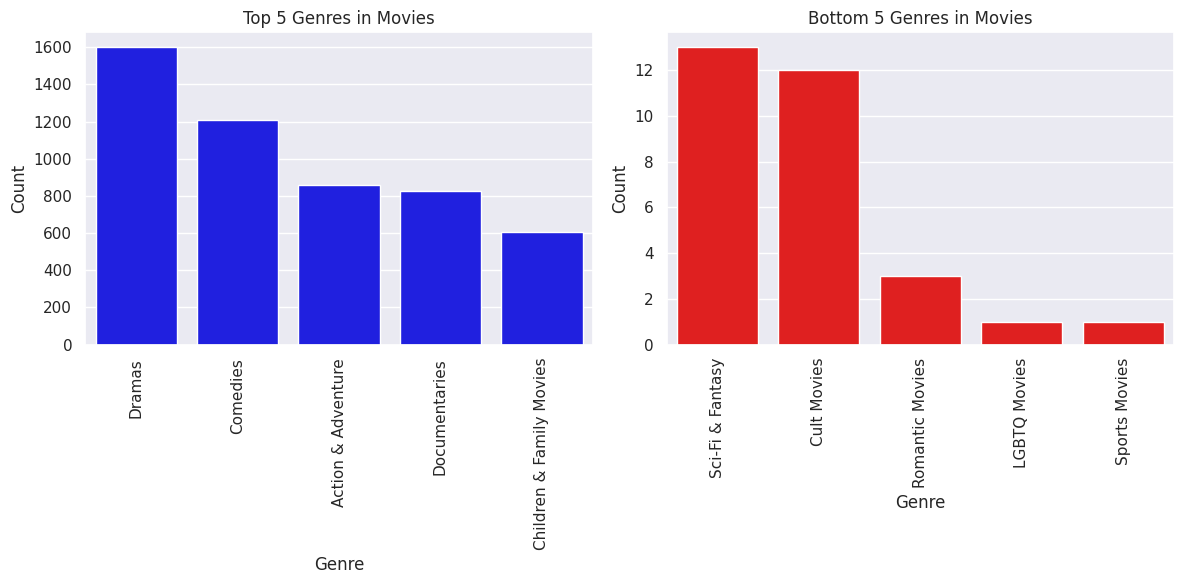

In [139]:
# Graphical Analysis

# Separate data for movies
movies_data = no_repeat_df_final[no_repeat_df_final['type'] == 'Movie']

# Getting top 5 genres for movies
top5_genres_movies = movies_data['genre'].value_counts().index[:5]
top5_movies = movies_data[movies_data['genre'].isin(top5_genres_movies)]

# Getting bottom 5 genres for movies
bottom5_genres_movies = movies_data['genre'].value_counts().index[-5:]
bottom5_movies = movies_data[movies_data['genre'].isin(bottom5_genres_movies)]

# Create figure for movies
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plotting top 5 genres for movies
sns.countplot(x='genre', data=top5_movies, order=top5_movies['genre'].value_counts().index, color='blue', ax=axes[0])
axes[0].set_title('Top 5 Genres in Movies')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Count')
plt.sca(axes[0])
plt.xticks(rotation=90)

# Plotting bottom 5 genres for movies
sns.countplot(x='genre', data=bottom5_movies, order=bottom5_movies['genre'].value_counts().index, color='red', ax=axes[1])
axes[1].set_title('Bottom 5 Genres in Movies')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Count')
plt.sca(axes[1])
plt.xticks(rotation=90)

# Adjust layout for movies plot
plt.tight_layout()
plt.show()


## **Observation :**

1.  The **Top 5 Movie genre** are shown on the LHS graph:

    **Top 2 Highest**
*   **Dramas** -- 1600 counts
*   **Comedies**  -- 1210 counts
*   **5th highest :Children and Family Movies**      605 counts


2.  The **Bottom 5 Movie genre** are shown on the RHS graph:

    The LGBTQ ,Sports Movies are only 1 in count each                    
            

**# Top , Bottom 5 Genre for TV Shows :**

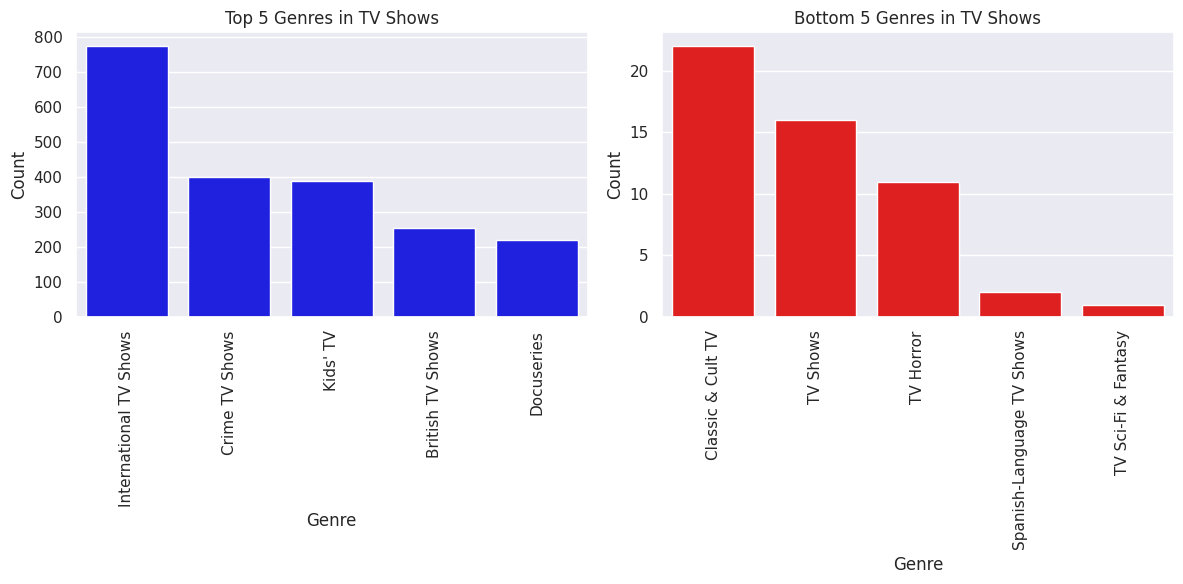

In [140]:
# Graphical Analysis

# Separate data for TV shows
tv_shows_data = no_repeat_df_final[no_repeat_df_final['type'] == 'TV Show']

# Getting top 5 genres for TV shows
top5_genres_tv = tv_shows_data['genre'].value_counts().index[:5]
top5_tv_shows = tv_shows_data[tv_shows_data['genre'].isin(top5_genres_tv)]

# Getting bottom 5 genres for TV shows
bottom5_genres_tv = tv_shows_data['genre'].value_counts().index[-5:]
bottom5_tv_shows = tv_shows_data[tv_shows_data['genre'].isin(bottom5_genres_tv)]

# Create figure for TV shows
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plotting top 5 genres for TV shows
sns.countplot(x='genre', data=top5_tv_shows, order=top5_tv_shows['genre'].value_counts().index, color='blue', ax=axes[0])
axes[0].set_title('Top 5 Genres in TV Shows')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Count')
plt.sca(axes[0])
plt.xticks(rotation=90)

# Plotting bottom 5 genres for TV shows
sns.countplot(x='genre', data=bottom5_tv_shows, order=bottom5_tv_shows['genre'].value_counts().index, color='red', ax=axes[1])
axes[1].set_title('Bottom 5 Genres in TV Shows')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Count')
plt.sca(axes[1])
plt.xticks(rotation=90)

# Adjust layout for TV shows plot
plt.tight_layout()
plt.show()


## **Observation :**

1.  The **Top 5 TV Show genre** are shown on the LHS graph:

*   **International TV Shows**  --        774 counts
*   **Crime TV Shows**        --        399 counts
*   **5th highest :Docuseries**     -- 221 counts


2.  The **Bottom 5 Movie genre** are shown on the RHS graph:

    Bottom 2 has Spanish-Language TV Shows,TV Sci-Fi & Fantasy shows with 2 and 1 counts respectively               1  

----------------------------------------------------------------------------------------------------------------------------------------------------------------

# **4.Visual Analysis :**

**4a.The continuous variables in currentdataset include:**


*   release_year
*   new_duration


**4a.1.Univariate Analysis Options:**


* **Distplot and Histogram:** These can be used to visualize the distribution of continuous variables.
* **Countplot:** Generally used for categorical data, but could be used if you want to see counts of unique values in release_year.

**Distplot and Histogram for Movies**

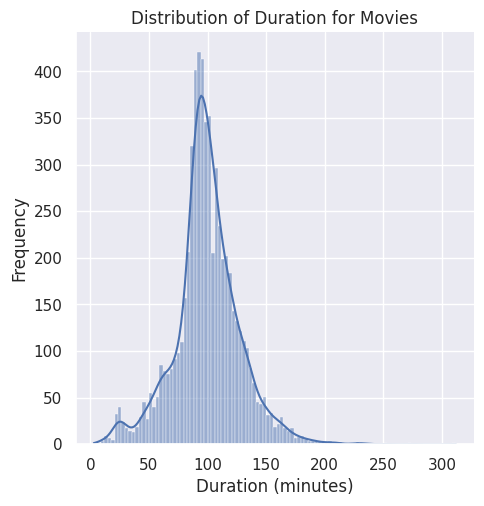

In [141]:
# Separate data for movies
movies_data = no_repeat_df_final[no_repeat_df_final['type'] == 'Movie']

# Distplot for new_duration (Movies)
sns.displot(movies_data['new_duration'], kde=True)
plt.title('Distribution of Duration for Movies')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

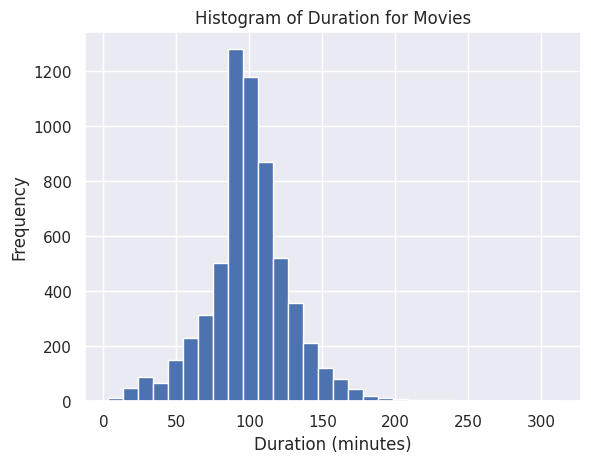

In [142]:

# Histogram for new_duration (Movies)
plt.hist(movies_data['new_duration'], bins=30)
plt.title('Histogram of Duration for Movies')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

## **Observation :**

Maximum number of movies have a duration of about 70 mins to 120 mins which maybe a sweet range for making movies.

**Distplot and Histogram for TV Shows**

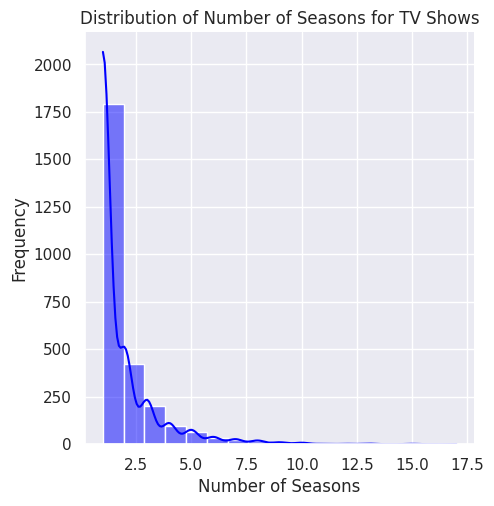

In [143]:
# Separate data for TV shows
tv_shows_data = no_repeat_df_final[no_repeat_df_final['type'] == 'TV Show']

# Distplot for new_duration (TV Shows in Seasons)
sns.displot(tv_shows_data['new_duration'], kde=True, bins=17, color='blue')
plt.title('Distribution of Number of Seasons for TV Shows')
plt.xlabel('Number of Seasons')
plt.ylabel('Frequency')
plt.show()

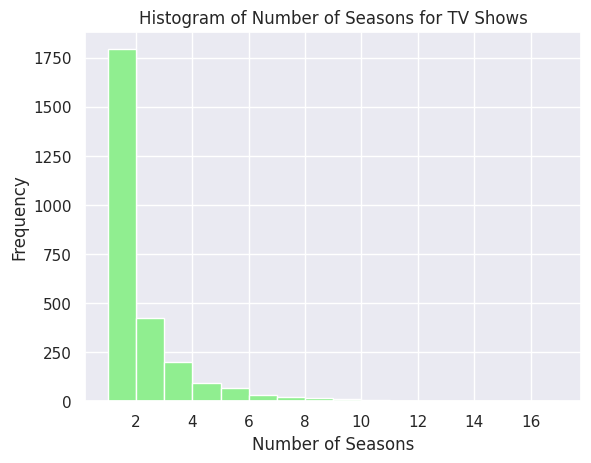

In [144]:
# Histogram for new_duration (TV Shows in Seasons)
plt.hist(tv_shows_data['new_duration'], bins=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 17], color='lightgreen')
plt.title('Histogram of Number of Seasons for TV Shows')
plt.xlabel('Number of Seasons')
plt.ylabel('Frequency')
plt.show()


## **Observation:**

Maximum number of TV Shows have 1 to 2 seasons . This shows the following posiibilities .


*   Either these TV Shows did not receive more attention from the audience and hence were discontinued after 1-2 seasons .
*  Some of them would be relatively new and are awaiting new season releases .
* It can be seen that very few TV Shows have more than 6 seasons and they must be real favourites for people to stick around .

**Recommendation:**


*   A deep study can be done regarding TV Shows with higher number of Seasons genre and style of making . More shows can be built around that genre to cater the needs of the major audience





### **4b.For categorical variables:**
The categorical variables in current dataset include:

*   type
*   country
*   rating
*   genre
*   month_name_added

**4b.1.Categorical Analysis Option:**

*  **Boxplot:** Typically used to visualize the distribution of a continuous variable across different categories.

***# Boxplot for Movies: new_duration by rating***

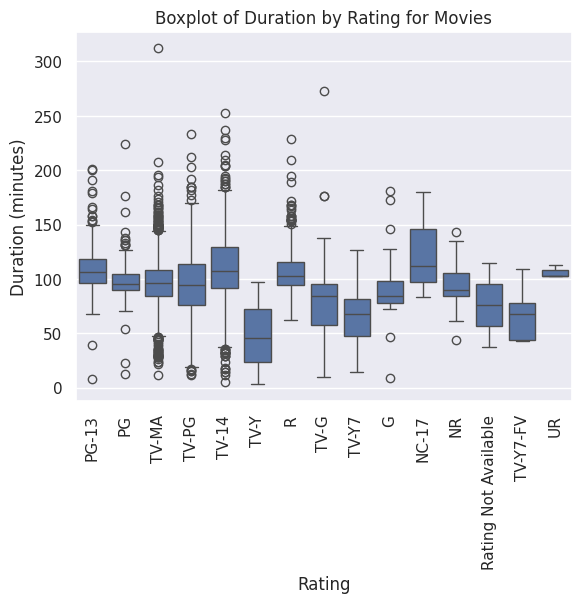

In [145]:
# Boxplot for new_duration by rating for Movies
sns.boxplot(x='rating', y='new_duration', data=movies_data)
plt.title('Boxplot of Duration by Rating for Movies')
plt.xlabel('Rating')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=90)
plt.show()

### **Boxplot of Duration by Rating for Movies**

1. **Median Duration**:
   - The median duration for most ratings is around 100 minutes, with some variations.
   - TV-PG, TV-14, and R-rated movies show a slightly higher median duration compared to other ratings.

2. **Spread and Variability**:
   - TV-PG and TV-14 ratings have a wide interquartile range (IQR), indicating high variability in movie durations within these ratings.
   - TV-MA and PG-13 also show a considerable spread, suggesting diverse content lengths.

3. **Outliers**:
   - There are significant outliers, especially in PG, TV-MA, TV-14, and TV-PG ratings, with some movies exceeding 200 minutes.
   - G and TV-G ratings have fewer outliers, indicating more consistency in movie lengths.

4. **Shorter Duration Categories**:
   - TV-Y and TV-Y7 have much shorter durations, reflecting their target audience of younger children.
   - TV-Y7-FV shows very little variability, with most movies around 50 minutes.

5. **Other Ratings**:
   - NC-17 and UR (Unrated) have a broad range but fewer entries, making it harder to generalize.
   - NR (Not Rated) movies have durations spread across a wide range but show more consistency compared to other ratings.


### **General Insights**

- **Diversity in Content**: Both ratings and genres show significant variability in movie durations, reflecting the diverse range of content available on Netflix.
- **Audience Targeting**: The duration of movies correlates with the target audience. For example, children's movies and TV-Y rated content are shorter, catering to younger viewers, whereas documentaries and dramas are longer, likely catering to an older audience.
- **Content Consistency**: Certain genres like Stand-Up Comedy and ratings like TV-Y7-FV show more consistency in movie durations, suggesting a standardized format for these types of content.

**#Boxplot for TV Shows : new_duration by rating**

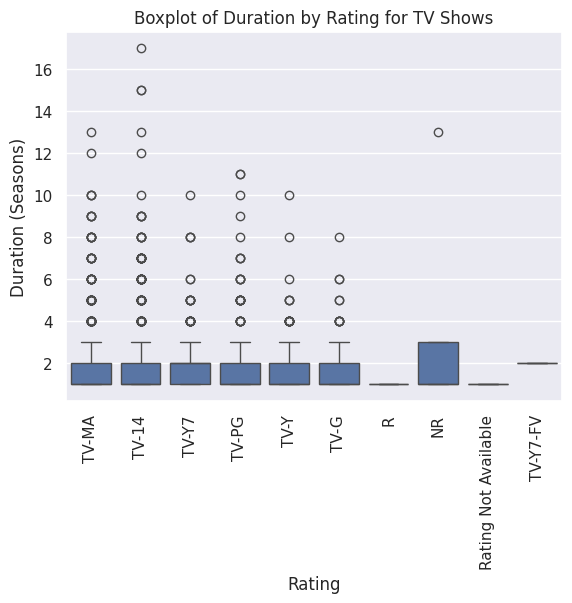

In [146]:
# Boxplot for new_duration by rating for TV Shows
sns.boxplot(x='rating', y='new_duration', data=tv_shows_data)
plt.title('Boxplot of Duration by Rating for TV Shows')
plt.xlabel('Rating')
plt.ylabel('Duration (Seasons)')
plt.xticks(rotation=90)
plt.show()

#### **Boxplot of Duration by Rating for TV Shows**

1. **Median Duration**:
   - Most TV shows across different ratings have a median duration of around 1-2 seasons.
   - The median duration is quite consistent regardless of the rating category.

2. **Variation in Duration**:
   - There is significant variation in the number of seasons for TV shows in the TV-MA, TV-14, and TV-Y7 ratings, as evidenced by the presence of numerous outliers.
   - TV-Y and TV-G shows tend to have a smaller range of seasons, indicating less variation in their duration.

3. **Outliers**:
   - TV-MA and TV-14 categories show several outliers, with some shows lasting up to 14-16 seasons.
   - Other ratings such as TV-Y7 and TV-PG also show a few outliers but not as extreme.

4. **Categories with Minimal Data**:
   - Some categories like R, NR, and TV-Y7-FV show very limited data with durations clustering around the lower end (1-2 seasons) and almost no variation.

**# Boxplot for Movies: new_duration by genre**

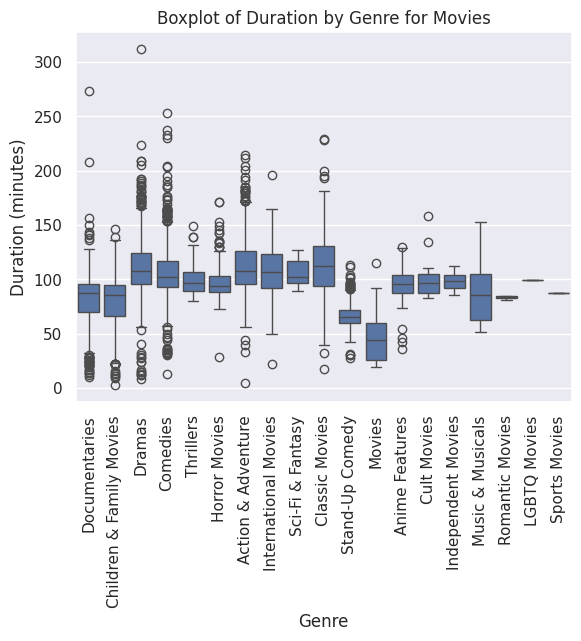

In [147]:
# Boxplot for new_duration by genre for Movies
sns.boxplot(x='genre', y='new_duration', data=movies_data)
plt.title('Boxplot of Duration by Genre for Movies')
plt.xlabel('Genre')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=90)
plt.show()

### **Boxplot of Duration by Genre for Movies**

1. **Median Duration**:
   - Most genres have a median duration close to 100 minutes.
   - Documentaries tend to be slightly longer, with a median duration over 100 minutes.

2. **Spread and Variability**:
   - Documentaries, Dramas, and Action & Adventure genres show a wide IQR, indicating high variability in movie lengths.
   - Stand-Up Comedy has a smaller IQR, showing more consistency in duration around the median, typically shorter than other genres.

3. **Outliers**:
   - Dramas, Documentaries, and Action & Adventure have significant outliers, with some movies exceeding 200 minutes.
   - Stand-Up Comedy and Anime Features also have notable outliers, though not as extreme.

4. **Shorter Duration Categories**:
   - Stand-Up Comedy shows the shortest durations, with most movies around 60 minutes.
   - Children's and Family Movies also tend to be on the shorter side, likely due to the attention span of the target audience.

5. **Other Observations**:
   - Independent Movies and Cult Movies show a wide range of durations, reflecting their diverse and often experimental nature.
   - Classic Movies and Sci-Fi & Fantasy have varied durations, with several outliers indicating a mix of both short and long-form content.
   - Music & Musicals and LGBTQ Movies have a more consistent range around the median, with fewer extreme outliers.


**# Boxplot for TV shows: new_duration by genre**

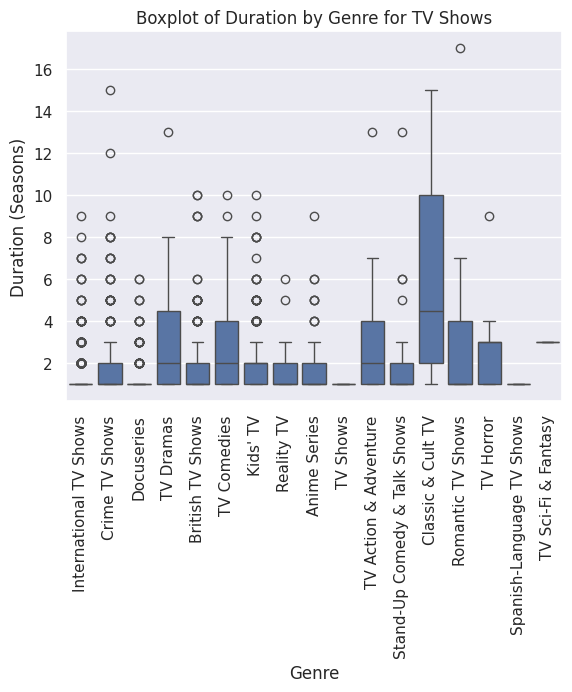

In [148]:
# Boxplot for new_duration by genre for TV Shows
sns.boxplot(x='genre', y='new_duration', data=tv_shows_data)
plt.title('Boxplot of Duration by Genre for TV Shows')
plt.xlabel('Genre')
plt.ylabel('Duration (Seasons)')
plt.xticks(rotation=90)
plt.show()

### **Insights from the Boxplots**


#### **Boxplot of Duration by Genre for TV Shows**

1. **Median Duration**:
   - The median duration across most genres is relatively low, around 1-3 seasons.
   - Notably, Classic & Cult TV shows tend to have a higher median duration, indicating these shows often have longer runs.

2. **Variation in Duration**:
   - Classic & Cult TV, TV Dramas, and TV Comedies show higher variation in the number of seasons, with many outliers indicating some shows in these genres can be quite long-running.
   - Genres like Kids' TV, Anime Series, and Reality TV have shorter durations with less variation.

3. **Outliers**:
   - Significant outliers are present in Classic & Cult TV, TV Dramas, and TV Comedies, with some shows reaching up to 16 seasons.
   - Outliers are also observed in genres like British TV Shows and TV Action & Adventure but are less pronounced.

4. **Genres with Consistent Duration**:
   - Genres such as Docuseries, Kids' TV, and Reality TV tend to have more consistent durations, with most shows clustering around 1-3 seasons and fewer outliers.
   - Spanish-Language TV Shows and TV Horror also display less variation in the number of seasons.

### **General Observations**

- **Ratings and Genres Influence Duration**:
  - TV shows with certain ratings (e.g., TV-MA, TV-14) and genres (e.g., Classic & Cult TV, TV Dramas) tend to have more variability in their durations, indicating a mix of both short and long-running shows.
  - Conversely, some ratings and genres tend to be more consistent in duration, suggesting these types of shows have more predictable lifespans.

- **Longevity of Shows**:
  - Classic & Cult TV shows are notable for their longevity, often lasting many seasons, which could be due to their cult following and sustained popularity.
  - On the other hand, genres targeted towards younger audiences (Kids' TV, Anime Series) typically have shorter runs, possibly due to the changing interests of the target demographic.

These insights can help in understanding the trends in TV show durations based on their ratings and genres, providing a useful perspective for content creators, distributors, and consumers.

## **4c.For correlation:**
To explore correlations between continuous variables:

*   release_year
*   new_duration


**4c.1.Correlation Analysis Options:**

*  **Heatmap:**Shows the correlation matrix between variables


**#Heatmap of Correlations for Movies**

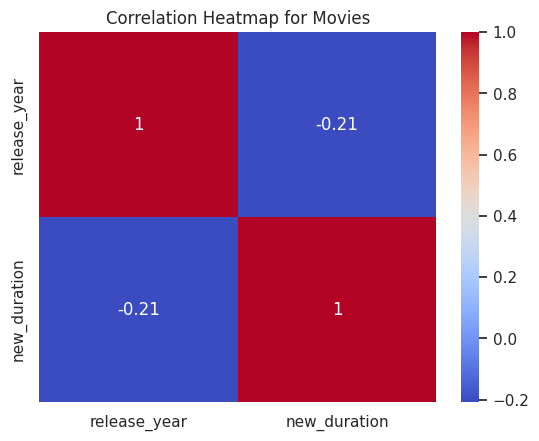

In [149]:
# Compute correlation matrix for movies
movies_corr_matrix = movies_data[['release_year', 'new_duration']].corr()

# Plot heatmap for movies
sns.heatmap(movies_corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for Movies')
plt.show()


**#Heatmap of Correlations for TV Shows**

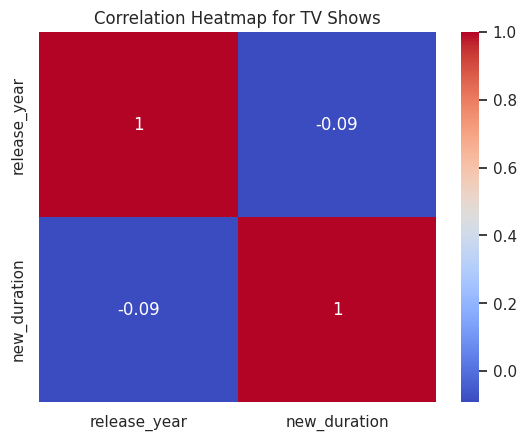

In [150]:
# Compute correlation matrix for TV shows
tv_shows_corr_matrix = tv_shows_data[['release_year', 'new_duration']].corr()

# Plot heatmap for TV shows
sns.heatmap(tv_shows_corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for TV Shows')
plt.show()

## **Observations on correlations:**

 * The heatmap shows a very low negative correlation (-0.21) between 'release_year', 'duration' which means with more recent years the duration  preferred for movies has decreased .i.e people are likely to favour shorter film as compared to very long films made before 2000.
 * However there are other factors affecting the scenarion. So the ideal movie time seems to be around 100 to 120 mins .
 * Not much can be said about the correlation between 'release_year', 'duration' for TV shows .

--------------------------------------------------------------------------------

# **Q2.Comparison of tv shows vs. movies.**

## **2a.Find the number of movies produced in each country and pick the top 10 countries**

In [151]:
# Getting df for only movies
movies_df = no_repeat_df_final[no_repeat_df_final["type"]=="Movie"]

# Group by country and count unique titles of movies
movie_counts_by_country = movies_df.groupby('country')['title'].nunique().sort_values(ascending=False)

# Pick top 10 countries
top_10_countries_movies = movie_counts_by_country.head(10)

# Convert to DataFrame with index starting from 1
top_10_countries_movies_df = top_10_countries_movies.reset_index()
top_10_countries_movies_df.index += 1

# Rename columns
top_10_countries_movies_df.columns = ['Country', 'Number of Movies Produced']


top_10_countries_movies_df.reset_index()
top_10_countries_movies_df


,Country,Number of Movies Produced
1,United States,2680
2,India,992
3,United Kingdom,386
4,Canada,190
5,France,150
6,Spain,129
7,Egypt,106
8,Nigeria,98
9,Japan,93
10,Mexico,90


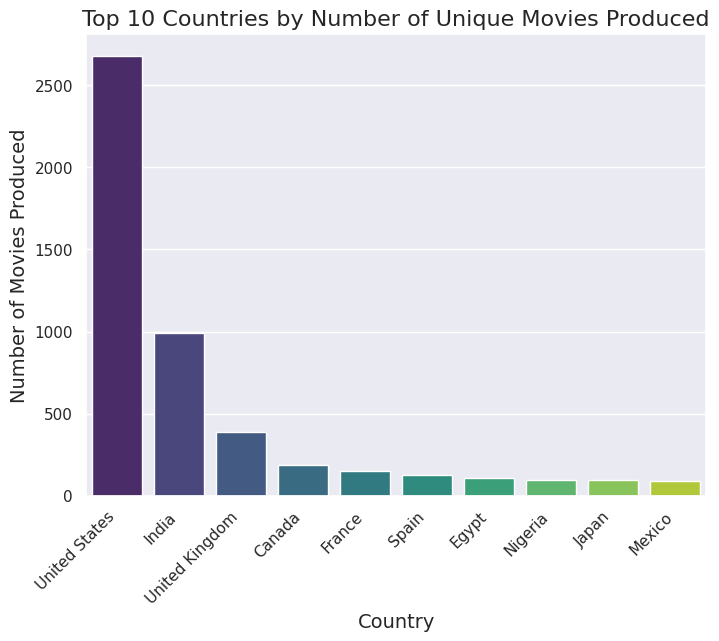

In [152]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_10_countries_movies_df,
    x='Country',
    y='Number of Movies Produced',
    hue='Country',
    dodge=False,
    palette='viridis',
    legend=False
)

# Adding title and labels
plt.title('Top 10 Countries by Number of Unique Movies Produced', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Number of Movies Produced', fontsize=14)

# Rotating the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Displaying the plot
plt.show()


## **2b.Find the number of Tv-Shows produced in each country and pick the top 10 countries**





In [153]:
#Hint : We want you to apply group by each country and find the count of unique titles of Tv-shows

# Filtering df for only tv_shows
tv_shows_df =  no_repeat_df_final[no_repeat_df_final["type"]=="TV Show"]

# Group by country and count unique titles of TV shows
tv_show_counts_by_country = tv_shows_df.groupby('country')['title'].nunique().sort_values(ascending=False)

# Pick top 10 countries
top_10_countries_tv_shows = tv_show_counts_by_country.head(10)

# Convert to DataFrame with index starting from 1
top_10_countries_tv_shows_df = pd.DataFrame(top_10_countries_tv_shows).reset_index()
top_10_countries_tv_shows_df.index += 1

# Rename columns
top_10_countries_tv_shows_df.columns = ['Country', 'Number of TV Shows Produced']


# Create a rank column based on the count of TV shows produced
top_10_countries_tv_shows_df['Rank'] = top_10_countries_tv_shows_df['Number of TV Shows Produced'].rank(ascending=False).astype(int)

# Reorder columns to place 'Rank' column first
top_10_countries_tv_shows_df = top_10_countries_tv_shows_df[['Rank', 'Country', 'Number of TV Shows Produced']]

# Display the dataframe
top_10_countries_tv_shows_df



,Rank,Country,Number of TV Shows Produced
1,1,United States,1231
2,2,United Kingdom,247
3,3,Japan,174
4,4,South Korea,164
5,5,Canada,84
6,6,India,81
7,7,Taiwan,71
8,8,France,65
9,9,Australia,56
10,10,Spain,54


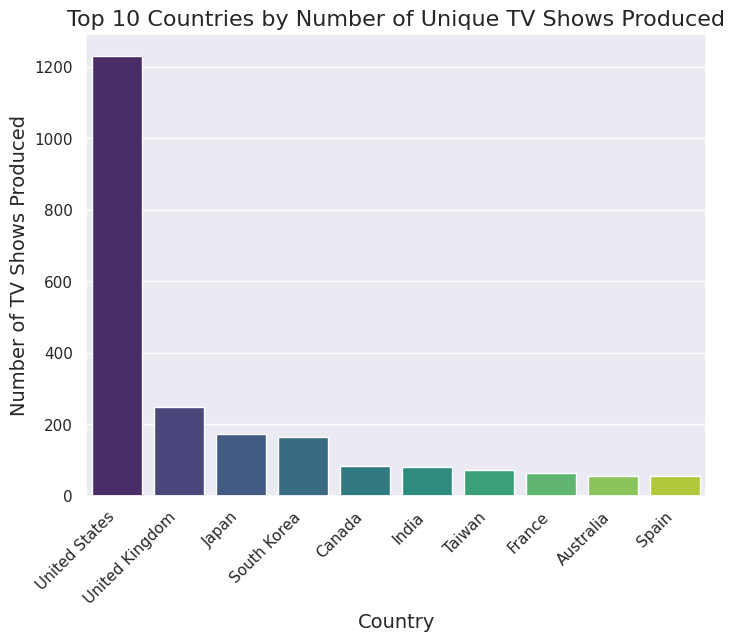

In [154]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_10_countries_tv_shows_df,
    x='Country',
    y='Number of TV Shows Produced',
    hue='Country',
    dodge=False,
    palette='viridis',
    legend=False
)

# Adding title and labels
plt.title('Top 10 Countries by Number of Unique TV Shows Produced', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Number of TV Shows Produced', fontsize=14)

# Rotating the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Displaying the plot
plt.show()


--------------------------------------------------------------------------------

# **3. What is the best time to launch a TV show?**


## **a. Find which is the best week to release the Tv-show or the movie. Do the analysis separately for Tv-shows and Movies**

**3.a.1For Movies:**

In [155]:
# Refer line 264 of above code where we have created a 'week_added' column
# as we cannot create this column in 'no_repeat_df_final' dataframe ..since its a slice of the original dataframe

# Filtering df for only movies
movies_df = no_repeat_df_final[no_repeat_df_final["type"]=="Movie"]

# Group by week_added and type (Movie) and count the number of movies
movie_weekly_counts = movies_df.groupby('week_added').size().sort_values(ascending=False).reset_index(name='Count of Movies Released')


# Find the week with the maximum number of movies
max_movie_week_df = movie_weekly_counts.loc[movie_weekly_counts["Count of Movies Released"].idxmax()]

max_movie_week = max_movie_week_df[0]
number_of_movies_in_that_week = max_movie_week_df[1]


print("Week with the highest number of Movies:", max_movie_week)
print("Number of movies released during that week:", number_of_movies_in_that_week)
movie_weekly_counts[:20]



Week with the highest number of Movies: 1
Number of movies released during that week: 316


,week_added,Count of Movies Released
0,1,316
1,44,243
2,40,215
3,9,207
4,26,195
5,35,189
6,31,185
7,13,174
8,18,173
9,27,154


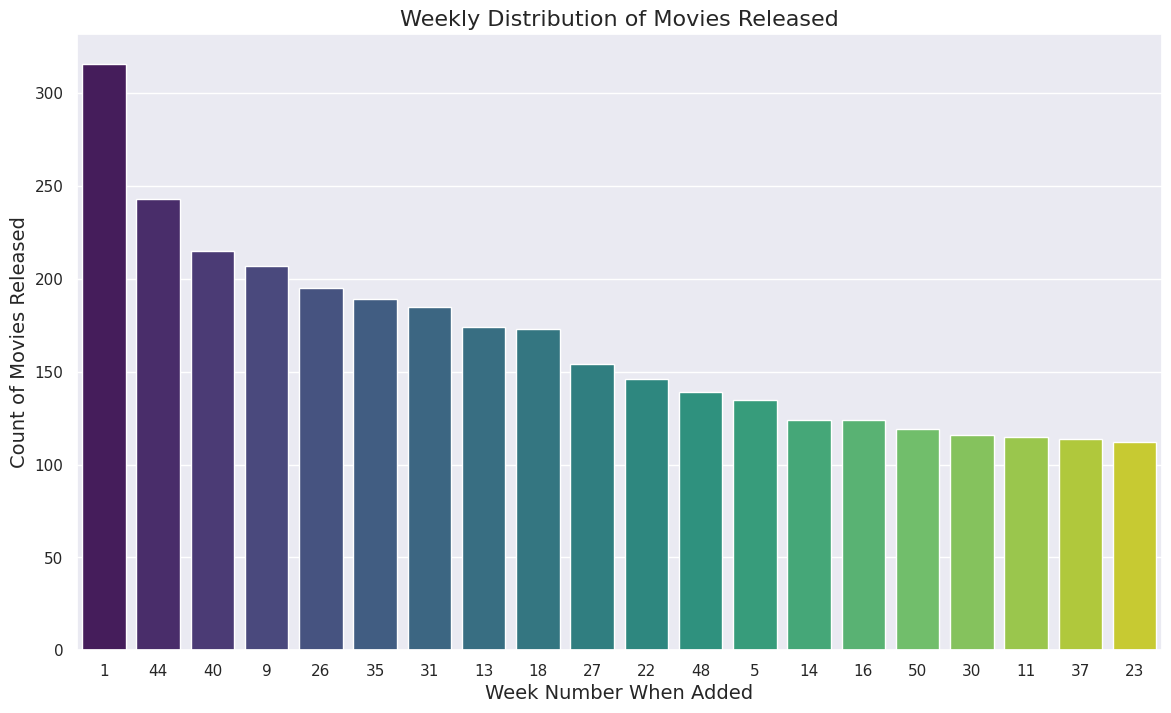

In [156]:
# Seaborn's barplot function expects the 'week_added' column to be categorical when using it as the 'hue'.

# Convert 'week_added' to categorical
movie_weekly_counts['week_added'] = movie_weekly_counts['week_added'].astype(str)

# Plotting
plt.figure(figsize=(14, 8))
sns.barplot(
    data=movie_weekly_counts.head(20),  # Plotting top 20 weeks
    x='week_added',
    y='Count of Movies Released',
    palette='viridis',
    hue='week_added',
    dodge=False,
    legend=False
)

# Adding title and labels
plt.title('Weekly Distribution of Movies Released', fontsize=16)
plt.xlabel('Week Number When Added', fontsize=14)
plt.ylabel('Count of Movies Released', fontsize=14)

# Displaying the plot
plt.show()


### **Observation :**



*   1st week of the year is the best time to release a Movie as the movies released during that is 316 in number .
*   1st week is the holiday season happen to lie in part December and part Jan as : In most ISO calendar systems, the first week of the year is the week that contains the first Thursday of the year. Therefore, week 1 usually contains some days from the previous year and some from the current year.


*    The second best is Week 44 with 243 releases . Week 44 generally falls towards the end of the year, typically in October or November.

**Week 1 release benefits:**

**Week 1 typically falls around the beginning of January.** This period is characterized by:

**New Year Celebrations:** Week 1 marks the start of the new year, and there is often a celebratory atmosphere worldwide. People may have time off work or school, making it an opportune time for movie releases to attract audiences looking for entertainment.

**Holiday Season:** The holiday season continues into early January, with many people still on vacation or spending time with family and friends. Movie releases during this time can capitalize on the holiday spirit and leisure time available to audiences.

**Awards Season:** January marks the beginning of the awards season in the film industry, with prestigious events like the Golden Globes and the Oscars taking place later in the month and in February. Releasing movies in week 1 allows them to be eligible for consideration and build momentum leading up to these awards ceremonies

**Week 44 release benefits:For Movie releases:**

**Week 44 typically falls around late October or early November.** This timeframe is characterized by:

**Fall Season:** Week 44 marks the transition into the fall season in the Northern Hemisphere. As the weather cools down, people may spend more time indoors, providing an opportunity for movie releases to attract audiences looking for entertainment options.

**Halloween:** Late October is associated with the Halloween holiday in many countries. Horror movies, thrillers, and other spooky-themed films are often released around this time to capitalize on the Halloween spirit and attract audiences seeking seasonal entertainment.

**School Breaks:** In some regions, week 44 may coincide with school breaks or holidays, such as fall break or midterm recess. Movie releases during this period can target families and students looking for activities during their time off.

**Awards Season Build-Up:** As the end of the year approaches, movie releases in week 44 can also aim to generate buzz and momentum leading into the upcoming awards season, which typically begins in January.

Overall, weeks 1 and 44 present opportunities for movie releases to align with holiday seasons, leisure time, and thematic trends, maximizing their potential for audience engagement and box office success.

**3a.2.For TV Shows:** A simpler code version

In [157]:
# Filtering df for only tv_shows
tv_shows_df = no_repeat_df_final[no_repeat_df_final["type"] == "TV Show"]

# # Convert 'date_added' column to datetime format
# tv_shows_df['date_added'] = pd.to_datetime(tv_shows_df['date_added'])

# # Extract week number from 'date_added' using isocalendar and create a new column 'week_added'
# tv_shows_df['week_added'] = tv_shows_df['date_added'].dt.isocalendar().week

# Group by week_added and type (TV Show) and count the number of TV shows
tv_show_weekly_counts = tv_shows_df.groupby('week_added').size()

# Find the week with the highest number of TV shows
max_tv_show_week = tv_show_weekly_counts.idxmax()


# Getting the count of TV shows released during the week with the highest number of TV show releases
num_tv_shows_max_week = tv_show_weekly_counts.loc[max_tv_show_week]  # Notice the df..counts

print("Week with the highest number of TV Shows:", max_tv_show_week)
print("Number of TV Shows released during that week:", num_tv_shows_max_week)


Week with the highest number of TV Shows: 27
Number of TV Shows released during that week: 86


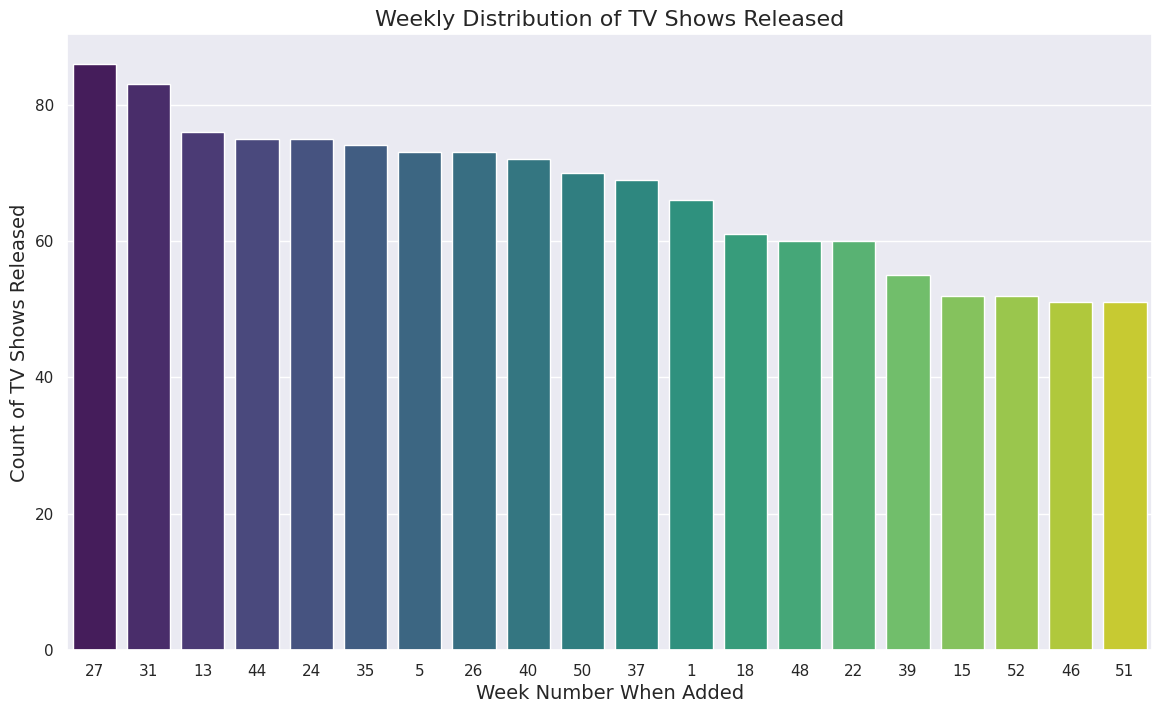

In [158]:
# Sorting tv_show_weekly_counts in descending order
tv_show_weekly_counts_sorted = tv_show_weekly_counts.sort_values(ascending=False)

# Convert 'week_added' to categorical
tv_show_weekly_counts_sorted.index = tv_show_weekly_counts_sorted.index.astype(str)

# Plotting
plt.figure(figsize=(14, 8))
sns.barplot(
    data=tv_show_weekly_counts_sorted.reset_index().head(20),  # Plotting top 20 weeks
    x='week_added',
    y=0,  # Use the count column
    palette='viridis',
    hue='week_added',
    dodge=False,
    legend=False
)

# Adding title and labels
plt.title('Weekly Distribution of TV Shows Released', fontsize=16)
plt.xlabel('Week Number When Added', fontsize=14)
plt.ylabel('Count of TV Shows Released', fontsize=14)

# Displaying the plot
plt.show()


### **Observation:**
The best time to release a TV show is Week 27 with around 86 releases during this week .

**Week 27 TV_Show release benefits:**
Week 27 typically falls around the end of June or the beginning of July, depending on the year. This timeframe often coincides with various factors that make it sensible for releasing TV shows:

**Summer Break:** In many countries, June and July mark the start of summer break for schools and colleges. With more people having leisure time during this period, releasing TV shows which require binge watch , many episodes can attract a larger audience.

**Vacation Season:** Many families plan vacations during the summer months, leading to increased TV viewership as people relax at home or in hotels.

**Festivals and Events**: Several festivals and events, such as Independence Day in the United States or Bastille Day in France, occur around this time. Releasing TV shows during these periods can capitalize on heightened entertainment consumption.

**Marketing Opportunities**: Advertisers often target summer months for promotions and marketing campaigns. Releasing TV shows during week 27 allows for better marketing opportunities and increased visibility.





## **3b. Find which is the best month to release the Tv-show or the movie. Do the analysis separately for Tv-shows and Movies**

**3b.1.For Movies**

In [159]:
# Group by month_name_added and type (Movie) and count the number of movies
movie_monthly_counts = no_repeat_df_final[no_repeat_df_final['type'] == 'Movie'].groupby('month_name_added').size()

# Find the month with the highest number of movies
max_movie_month = movie_monthly_counts.idxmax()

# Getting the count of movies released during the month with the highest number of movie releases
num_movies_max_month = movie_monthly_counts.loc[max_movie_month]

print("Month with the highest number of Movies:", max_movie_month)
print("Number of Movies released during that month:", num_movies_max_month)


Month with the highest number of Movies: Jul
Number of Movies released during that month: 565


### **Observation:**

**July has the highest number of movie releases, with a total of 565 movies released during that month.**

Possible reasons for this observation could include:

Note: The majority Movies come from US and western countries .Hence a major trend is set by these countries . However we can customize the analysation as per country .

**Summer Blockbusters:** July is often known as the peak of the summer movie season, with studios releasing major blockbuster films to attract audiences during the summer vacation period.

**School Holidays:** Many countries have school holidays during July, leading to increased leisure time for families and individuals. Movie studios may capitalize on this by releasing a diverse range of films to cater to different audience demographics.

**International Film Festivals:** Notably, Cannes Film Festival, held in May, and Sundance Film Festival, in January, often serve as platforms for premiering films that later receive wider releases. This trend contributes to the higher number of movie releases in July, following these prestigious events.

**Historical Trends:** Over the years, July has established itself as a prime month for movie releases, leading studios to schedule their releases strategically to maximize box office revenue.

**3b.2.For TV-Shows:**

In [160]:
# Group by month_name_added and type (TV Show) and count the number of TV shows
tv_show_monthly_counts = no_repeat_df_final[no_repeat_df_final['type'] == 'TV Show'].groupby('month_name_added').size()

# Find the month with the highest number of TV shows
max_tv_show_month = tv_show_monthly_counts.idxmax()

# Getting the count of TV shows released during the month with the highest number of TV show releases
num_tv_shows_max_month = tv_show_monthly_counts.loc[max_tv_show_month]

print("Month with the highest number of TV Shows:", max_tv_show_month)
print("Number of TV Shows released during that month:", num_tv_shows_max_month)


Month with the highest number of TV Shows: Dec
Number of TV Shows released during that month: 266


### **Observation:**

**December is the month with the highest number of TV shows released with 266 TV Shows released during this Mon**th.

**Holiday Season:** December sees a surge in TV show releases, likely due to the holiday season. Networks and streaming platforms may capitalize on increased viewership during this time.

**End-of-Year Releases:** TV networks and platforms may strategically release new shows in December to attract audiences during the end-of-year period when many people have time off work or school.

**Programming Strategies**: Networks and streaming services may aim to capture audience attention with new releases before the end of the calendar year, possibly to boost subscription numbers or ad revenue.

**Competition with Films:** While December is known for blockbuster movie releases, TV networks and streaming platforms may offer a diverse range of shows to compete for viewers' attention.

**Variety of Genres:**  With a high number of TV shows released in December, there's likely a wide variety of genres and themes to cater to different audience preferences during the holiday season.

Overall, December emerges as a significant month for TV show releases, with networks and streaming platforms strategically timing their releases to capitalize on increased viewership and holiday entertainment trends.

# **4. Analysis of actors/directors of different types of shows/movies.**


## **4a.Identify the top 10 actors who have appeared in most movies or TV shows.**

Here we will use the df_final dataset since the Actors for each title are unique only . If we try to use 'no_repeat_df_final' , it might have dropped all the actors and kept just the title with only the first actor


**Important :** If we consider the country column also then we see that Unknown actors from different countries are present in Top 10 Actors.

** Hence we have analysed the data with and without country .**



**4a.1.Considering country of Actors:**

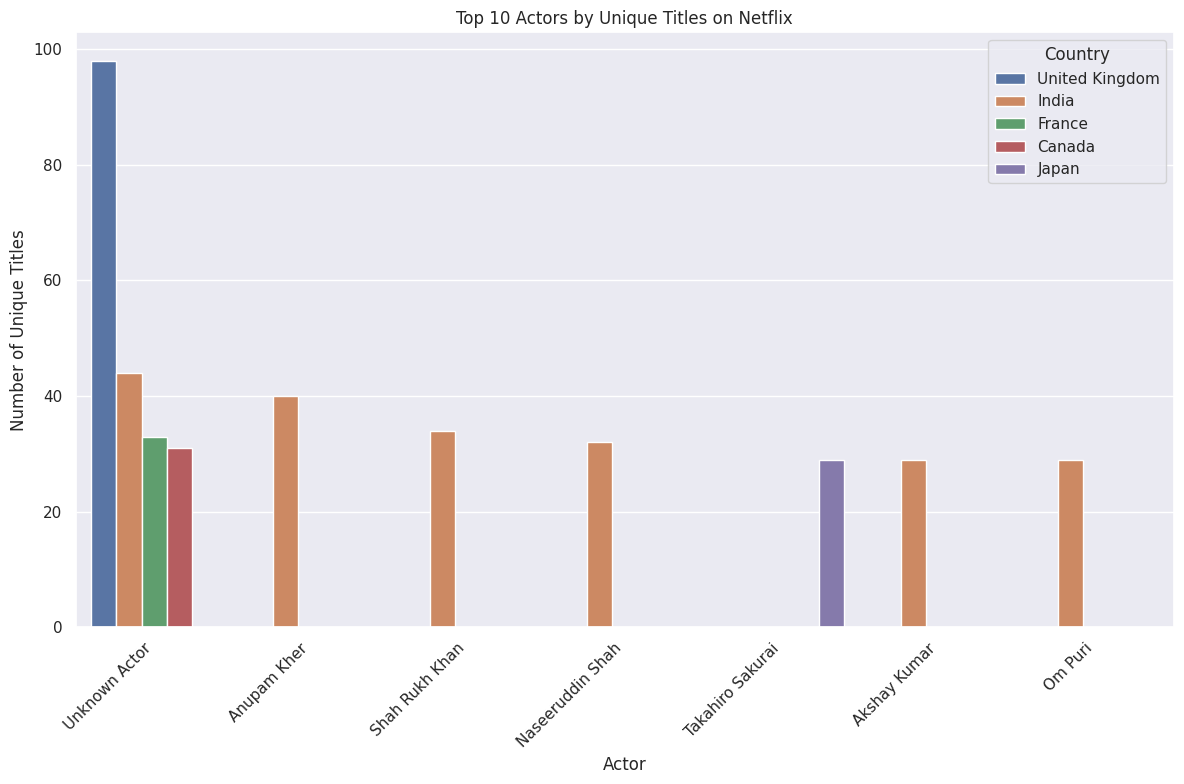

,cast,country,Title Count
0,Unknown Actor,United States,551
1,Unknown Actor,United Kingdom,98
2,Unknown Actor,India,44
3,Anupam Kher,India,40
4,Shah Rukh Khan,India,34
5,Unknown Actor,France,33
6,Naseeruddin Shah,India,32
7,Unknown Actor,Canada,31
8,Takahiro Sakurai,Japan,29
9,Akshay Kumar,India,29


In [161]:
# Group by each actor and count the number of unique titles they have appeared in
actor_title_counts = df_final.groupby(['cast', 'country'])['title'].nunique()

# Sort the counts in descending order and get the top 10 actors
top_10_actors = actor_title_counts.sort_values(ascending=False).head(11)

# Convert top_10_actors Series to DataFrame for barplot (requires a DataFrame not a Series)
top_10_actors_df = top_10_actors.reset_index(name='Title Count')

# Plot the top 10 actors with country as hue using sns.barplot
plt.figure(figsize=(12, 8))
sns.barplot(data=top_10_actors_df[1:11], x='cast', y='Title Count', hue='country')
plt.title('Top 10 Actors by Unique Titles on Netflix')
plt.xlabel('Actor')
plt.ylabel('Number of Unique Titles')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Country')
plt.tight_layout()
plt.show()

top_10_actors_df


**4a.2.Without Considering Country of Actors and ignoring 'Unknown Actors' which top the chart :**


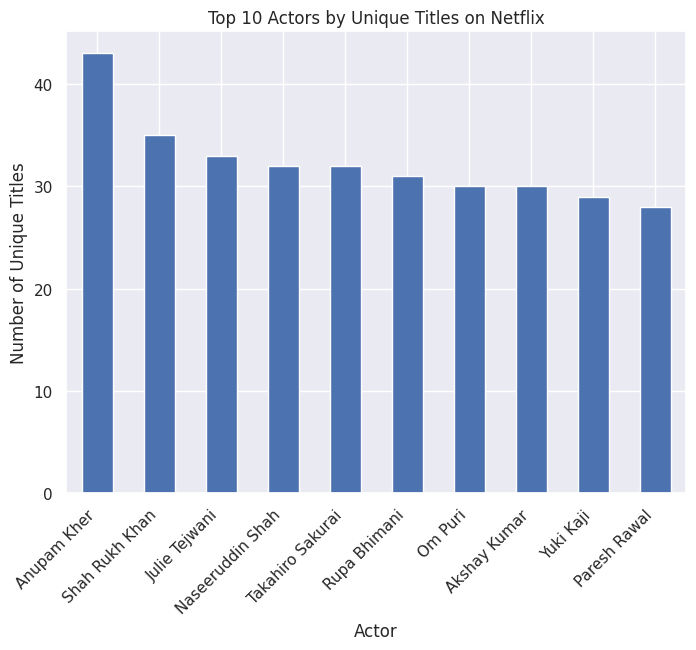

,cast,Title Count
1,Anupam Kher,43
2,Shah Rukh Khan,35
3,Julie Tejwani,33
4,Naseeruddin Shah,32
5,Takahiro Sakurai,32
6,Rupa Bhimani,31
7,Om Puri,30
8,Akshay Kumar,30
9,Yuki Kaji,29
10,Paresh Rawal,28


In [162]:
# Group by each actor and count the number of unique titles they have appeared in
actor_title_counts = df_final.groupby(['cast'])['title'].nunique()

# Sort the counts in descending order and get the top 10 actors
top_10_actors = actor_title_counts.sort_values(ascending=False).head(11)

# Display the top 10 actors
#print(top_10_actors)

# Convert top_10_actors Series to DataFrame for barplot ( requires a dataframe not a series)
top_10_actors_df = top_10_actors.reset_index(name='Title Count')


# Plot the top 10 actors excluding 'Unknown Actor' as it is a mixed set  and doesn't belong to the top rank
plt.figure(figsize=(8,6))
top_10_actors[1:11].plot(kind='bar')
plt.title('Top 10 Actors by Unique Titles on Netflix')
plt.xlabel('Actor')
plt.ylabel('Number of Unique Titles')
plt.xticks(rotation=45, ha='right')
plt.show()

top_10_actors_df[1:11]

**Observations:**

**Note :** By removing the data for Unknown actor, we ensure a more focused analysis of actors who have made meaningful contributions to Netflix's content ecosystem.

**Popular Indian Actors:**The top 10 places are significantly occupied by Indian Actors. The presence of actors like Anupam Kher, Shah Rukh Khan, Om Puri, Boman Irani, and Paresh Rawal highlights their significant contributions to Netflix's content. These actors are well-known figures in Indian cinema, and their appearance in numerous titles reflects their widespread popularity among audiences.

**Voice Actors in Anime:** Actors such as Rupa Bhimani, Takahiro Sakurai, Rajesh Kava, and Yuki Kaji are known for their voice acting work, particularly in anime. Despite not being as widely recognized in mainstream cinema, they have made notable contributions to the anime industry and have gained recognition for their talent.

**Global Appeal:** The presence of actors from various countries, including India and Japan, underscores Netflix's commitment to catering to diverse audiences worldwide. Featuring actors from different cultural backgrounds enriches the platform's content and allows viewers to explore stories from various regions.

**Insights for Content Creation:** Content creators and producers can use the popularity of actors like Anupam Kher, Shah Rukh Khan, and others to inform their content creation strategies. Leveraging the appeal of these actors can help attract viewership and enhance the overall quality of content on the platform.

**Opportunities for Diversity:** While recognizing the contributions of established actors, there is also an opportunity to promote diversity and inclusion by featuring actors from underrepresented regions and communities. Highlighting actors from diverse backgrounds can enrich the content offering and resonate with a broader audience base.

**Top 10 Actors for Movies only separately:**

In [163]:
actor_title_counts = df_final[df_final["type"]=="Movie"].groupby(['cast'])['title'].nunique().sort_values(ascending=False)[1:11]
actor_title_counts

cast
Anupam Kher         42
Shah Rukh Khan      35
Naseeruddin Shah    32
Om Puri             30
Akshay Kumar        30
Amitabh Bachchan    28
Paresh Rawal        28
Julie Tejwani       28
Boman Irani         27
Rupa Bhimani        27
Name: title, dtype: int64

**Top 10 Actors for TV Shows separately:**

In [164]:
actor_title_counts = df_final[df_final["type"]=="TV Show"].groupby(['cast'])['title'].nunique().sort_values(ascending=False)[1:11]
actor_title_counts

cast
Takahiro Sakurai      25
Yuki Kaji             19
Daisuke Ono           17
Ai Kayano             17
Junichi Suwabe        17
Yuichi Nakamura       16
Jun Fukuyama          15
Yoshimasa Hosoya      15
David Attenborough    14
Vincent Tong          13
Name: title, dtype: int64

## **4b. Identify the top 10 directors who have appeared in most movies or TV shows**

Here we will use the df_final dataset since the director for each title are unique only . If we try to use 'no_repeat_df_final' , it might have dropped all the director and kept just the title with only the first director

**Important :** If we consider the country column also then we see that Unknown directors from different countries are present in Top 10 directors.

**Hence we have analysed the data with and without country.**

**4b.1.Without Considering Country of Directors and ignoring 'Unknown Directors' which top the chart :**

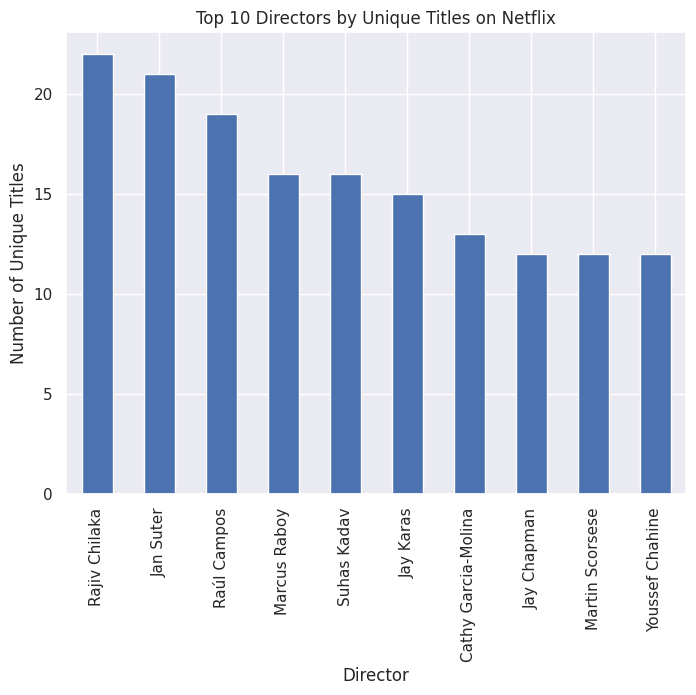

,director,Title Count
0,Unknown Director,2634
1,Rajiv Chilaka,22
2,Jan Suter,21
3,Raúl Campos,19
4,Marcus Raboy,16
5,Suhas Kadav,16
6,Jay Karas,15
7,Cathy Garcia-Molina,13
8,Jay Chapman,12
9,Martin Scorsese,12


In [165]:
# Group by each director and count the number of unique titles they have appeared in
director_title_counts = df_final.groupby(['director'])['title'].nunique()

# Sort the counts in descending order and get the top 10 directors
top_10_directors = director_title_counts.sort_values(ascending=False).head(11)

# Display the top 10 directors
#print(top_10_directors)

# Convert top_10_directors Series to DataFrame for barplot ( requires a dataframe not a series)
top_10_directors_df = top_10_directors.reset_index(name='Title Count')

# Plot the top 10 directors excluding 'Unknown Director' as it is a mixed set and doesn't belong to the top rank
plt.figure(figsize=(8,6))
top_10_directors[1:11].plot(kind='bar')
plt.title('Top 10 Directors by Unique Titles on Netflix')
plt.xlabel('Director')
plt.ylabel('Number of Unique Titles')
plt.xticks()
plt.show()

top_10_directors_df


**Top 10 Directors for Movies only separately:**

In [166]:
director_title_counts = df_final[df_final["type"]=="Movie"].groupby(['director'])['title'].nunique().sort_values(ascending=False)[1:11]
director_title_counts

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           15
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Jay Chapman            12
Youssef Chahine        12
Name: title, dtype: int64

**Top 10 Directors for TV Shows separately:**

In [167]:
director_title_counts = df_final[df_final["type"]=="TV Show"].groupby(['director'])['title'].nunique().sort_values(ascending=False)[1:11]
director_title_counts

director
Ken Burns                3
Alastair Fothergill      3
Stan Lathan              2
Joe Berlinger            2
Hsu Fu-chun              2
Gautham Vasudev Menon    2
Iginio Straffi           2
Lynn Novick              2
Shin Won-ho              2
Rob Seidenglanz          2
Name: title, dtype: int64

**Insights and Observations for Top 10 Directors:**
*  Indian and American directors prominently feature in the list, highlighting the significant contributions of Indian and American content to Netflix's content ecosystem.
*  The top 10 directors represent a diverse range of countries, showcasing Netflix's global reach and its commitment to offering content that appeals to diverse audience preferences and cultural backgrounds.
*  The presence of directors from emerging markets like the Philippines, Egypt, and Turkey underscores Netflix's efforts to promote diversity and inclusivity in its content offerings.
* Collaboration between established filmmakers and emerging talent provides opportunities for cross-cultural storytelling and audience engagement, enriching Netflix's content library with a wide variety of narratives and perspectives.

**Actionable Plans:**

* **Content Partnerships:** Forge strategic partnerships with top directors from India and the United States to produce exclusive content that caters to diverse audience preferences.
* **Regional Content Expansion:** Invest in acquiring and producing content from emerging markets to expand Netflix's regional content library and promote cultural exchange.
* **Director Development Programs:** Launch initiatives to support the development of emerging directors from underrepresented regions, including India and other emerging markets.
* **Cultural Exchange Programs:** Facilitate cross-cultural collaborations between directors from different countries to create engaging and culturally relevant content that resonates with global audiences.
* **Audience Engagement Initiatives:** Gather feedback from viewers to understand content preferences and tailor offerings accordingly, ensuring that diverse content is accessible and appealing to a wide range of audiences.
* **Marketing and Promotion:** Develop targeted marketing campaigns to promote content from top directors and highlight the diversity of Netflix's content library, including content from India, the United States, and other regions.
Talent Development: Invest in talent development programs to empower filmmakers and encourage creative experimentation, fostering the growth of diverse voices within the industry.
* **Sustainability and Inclusivi**ty: Ensure that all initiatives prioritize sustainability and inclusivity, promoting equitable opportunities for filmmakers from diverse backgrounds and regions.

By implementing these actionable plans, Netflix can continue to strengthen its position as a leading global streaming platform while enriching its content library with a wide variety of narratives that reflect the diverse cultural backgrounds and preferences of its audience.

**----------------------------------------------------------------------------------------------------------------------------------------------------------------:**

# **5. Which genre movies are more popular or produced more**

We will apply the word cloud on the genre columns to know which kind
of genre is produced more

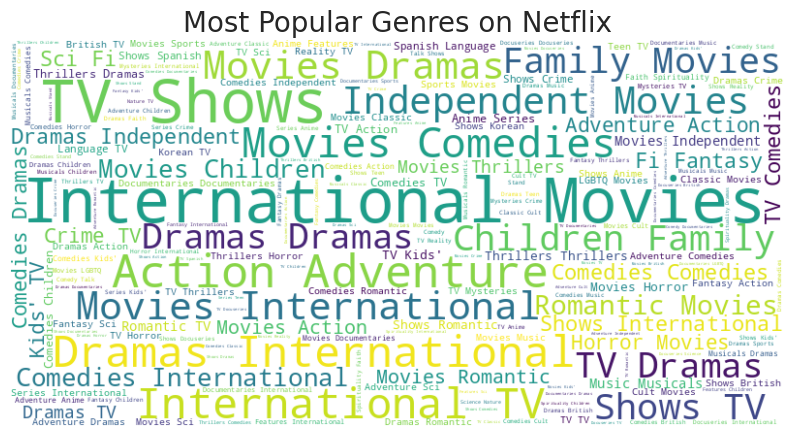

In [168]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Combine all genres into a single string
all_genres = ' '.join(df_final['genre'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_genres)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.title('Most Popular Genres on Netflix', fontsize=20)
plt.show()

### **Insights and Observations from the Word Cloud**

**Dominant Genres**:
- **International Movies** and **TV Shows** are among the most frequently produced genres on Netflix, indicating a strong emphasis on global content to cater to a diverse audience.
- **Dramas** and **Comedies** also feature prominently, reflecting their universal appeal and consistent demand.

**Variety of Genres**:
- The word cloud showcases a wide variety of genres, from **Action & Adventure** and **Romantic Movies** to **Children & Family Movies** and **Stand-Up Comedy**. This variety highlights Netflix's strategy to offer something for every type of viewer.

**Family-Oriented Content**:
- **Children & Family Movies** appear significantly, suggesting that family-oriented content is a key focus area for Netflix, aiming to attract viewers of all ages.

**Specialized Content**:
- Genres such as **Crime TV Shows**, **Horror Movies**, and **Sci-Fi** suggest that Netflix is also targeting niche audiences with specialized interests.

**Cultural Diversity**:
- The prominence of genres like **British TV Shows** and **Spanish-Language TV Shows** indicates Netflix's effort to include culturally specific content, catering to regional preferences and international audiences.

**Emerging Genres**:
- Genres like **Independent Movies** and **Anime** are also visible, which might indicate growing interest and investment in these areas to capture newer audience segments.

### **Observations**

- **Global Appeal**: The emphasis on **International Movies** and **TV Shows** aligns with Netflix's global expansion strategy, aiming to penetrate markets worldwide by offering localized and culturally relevant content.
- **Broad Demographic Reach**: The presence of diverse genres, including **Children & Family Movies**, **Romantic Movies**, and **Action & Adventure**, shows Netflix's commitment to serving a broad demographic range, from children to adults.
- **Balancing Popular and Niche Content**: Netflix's content library is well-balanced between widely popular genres like **Dramas** and **Comedies** and niche genres like **Horror Movies** and **Sci-Fi**, ensuring broad and deep engagement with its audience.
- **Inclusivity and Representation**: The variety of genres like LGBTQ movies,movies from different countries etc reflects Netflix's focus on inclusivity and representation, aiming to provide content that resonates with different cultures, languages, and interests.

This comprehensive mix of genres is likely designed to maximize viewer retention and attract new subscribers by continuously expanding the content offerings to match evolving viewer preferences.

**---------------------------------------------------------------------------------------------------------------------------------------------------------------:**

# **6. Find After how many days the movie will be added to Netflix after the release of the movie (you can consider the recent past data)**

In [169]:
# Using no_repeat_df_final dataframe to avoid duplicates

# Convert 'date_when_added' to datetime format
no_repeat_df_final.loc[:, 'date_when_added'] = pd.to_datetime(no_repeat_df_final['date_when_added'])

# Create a new column 'release_date' by converting 'release_year' to datetime format (using January 1st as a placeholder for the date)
no_repeat_df_final.loc[:, 'release_date'] = pd.to_datetime(no_repeat_df_final['release_year'], format='%Y')

# Calculate the difference in days between 'date_when_added' and 'release_date'
no_repeat_df_final.loc[:, 'days_to_add'] = (no_repeat_df_final['date_when_added'] - no_repeat_df_final['release_date']).dt.days

# Display the first few rows to verify the calculations
print(no_repeat_df_final[['title', 'release_year', 'date_when_added', 'days_to_add']].head())

# Calculate the mode of the difference in days. If there are multiple modes, choose the first one using mode()[0]
days_to_add_mode = no_repeat_df_final['days_to_add'].mode()[0]

# Display the mode
print()
print(f"The mode of the number of days it takes for a movie to be added to Netflix after its release is:{days_to_add_mode} days")

                    title  release_year date_when_added  days_to_add
0    Dick Johnson Is Dead          2020      2021-09-25          633
1           Blood & Water          2021      2021-09-24          266
58              Ganglands          2021      2021-09-24          266
85  Jailbirds New Orleans          2021      2021-09-24          266
87           Kota Factory          2021      2021-09-24          266

The mode of the number of days it takes for a movie to be added to Netflix after its release is:334 days


<ipython-input-169-cbd24ca204e8>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_repeat_df_final.loc[:, 'release_date'] = pd.to_datetime(no_repeat_df_final['release_year'], format='%Y')
<ipython-input-169-cbd24ca204e8>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_repeat_df_final.loc[:, 'days_to_add'] = (no_repeat_df_final['date_when_added'] - no_repeat_df_final['release_date']).dt.days


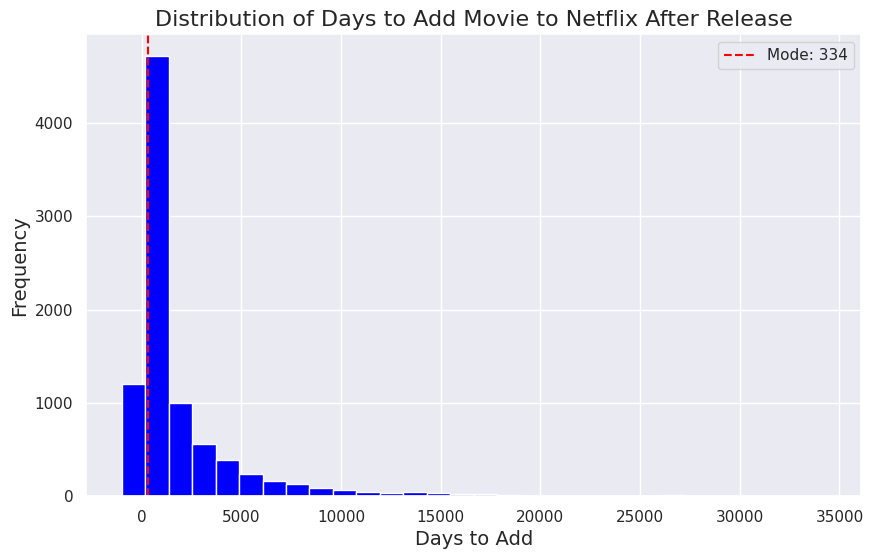

In [170]:
# Calculate mode of 'days_to_add'
days_to_add_mode = no_repeat_df_final['days_to_add'].mode()[0]

# Plotting
plt.figure(figsize=(10, 6))
plt.hist(no_repeat_df_final['days_to_add'], bins=30, color='blue')

# Adding vertical line for mode
plt.axvline(x=days_to_add_mode, color='red', linestyle='--', label=f'Mode: {days_to_add_mode}')

# Adding title, labels, and legend
plt.title('Distribution of Days to Add Movie to Netflix After Release', fontsize=16)
plt.xlabel('Days to Add', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()

# Displaying the plot
plt.show()


### **Observation:**

Based on the data provided, the most common duration it takes for a movie to be added to Netflix after its release is approximately 10.9 i.e approx 11 months.

*  **Content Acquisition Strategy:**Netflix tends to acquire movies nearly a year after their initial release. This may align with their strategy to provide relatively recent content while avoiding the high costs of acquiring films immediately after their release.


* **Licensing Agreements:**The 334-day gap could reflect common licensing agreements and negotiations between Netflix and movie distributors. It might be a standard period that aligns with contractual terms or market dynamics.


* **Market Positioning:**By adding movies around 11 months post-release, Netflix may be aiming to attract viewers who missed the movie in theaters or on other platforms, thus providing a second opportunity to watch relatively recent content.


* **Content Refresh Cycle:**This duration might fit into Netflix’s content refresh cycle, where they periodically update their library with new titles to keep the catalog fresh and engaging for subscribers.


**Problems that may arise:**

*  **Viewer Expectations:**Viewers might start expecting to see recent movies on Netflix about a year after their release, which could influence their subscription decisions and viewing habits.


* **Competitive Edge:**If competitors release content sooner, Netflix might need to consider adjusting their acquisition timelines to remain competitive, especially for high-demand titles.


* **Content Planning:**Understanding this typical delay can help Netflix in planning marketing campaigns, promotional activities, and content releases around this timeline to maximize viewer engagement.


* **Create Original Content:**This pattern might suggest a balance between acquiring third-party content and focusing on producing and releasing Netflix Originals, which are available exclusively and immediately on their platform.
International Markets:

* The 334-day timeline might vary for different regions based on local market conditions, preferences, and licensing deals, suggesting the need for tailored strategies in different international markets.


**-------------------------------------------------------------------------------------------------------------------------------------------------------------**

 **-----------------------------------------------------------------------------------------------------------------------------------------------------------**

# **Key Observations:**

1. **Dominance by Country: Contentwise**
    1. **United States** is the dominant player followed by India in terms of content creation and appeal to World audience.
    2. Around 50% Content is reserved with US and India (44%, 12% respectively) origin and rest 50% resides with the World.
    3. Rest are countries like UK, Canada, Japan, France, South Korea, Spain, Mexico, Egypt, Australia, Turkey, and the rest of the world with just 17% contribution.

2. **Contribution of Country to Movies/TV Shows:**
    1. **Movies are dominated by:** United States, India, UK, Canada, France with counts 2680, 992, 386 movies showing a vast difference between each countries movies produced.
    2. **For TV Shows :** the countries that dominate the platform are: United States, United Kingdom, Japan, South Korea, Canada.
    3. India is 6th in rank. TV content from US, Japan like Animes, South Korean drama have a huge fan following around the world.

3. **Actor Dominance:**
    1. **Popular Indian Actors For Overall Content:** Though US top for number of content but Indian actors seem to be global favourite. The top 10 places are significantly occupied by Indian Actors. The presence of actors like ,Anupam Kher, Shah Rukh Khan, Om Puri, Boman Irani, and Radhika Apte ,Paresh Rawal highlights their significant contributions to Netflix's content. These actors are well-known figures in Indian cinema, and their appearance in numerous titles reflects their widespread popularity among audiences.
    2. **Popular for TV Shows (Overall Content):** Japanese Voice actors dominate this space. Actors such as Takahiro Sakurai, Yuki Kaji, Daisuke Ono mostly all top 10 and then Rupa Bhimani, Rajesh Kava are known for their voice acting work, particularly in Anime. Despite not being as widely recognized in mainstream cinema, they have made notable contributions to the anime industry and have gained recognition for their talent.
   
      

4. **Director Dominance:**
    1. Indian and American directors prominently feature in the top 10 directors’ list.
    2. The top 10 directors represent a diverse range of countries – US, India, Mexico, Philippines, Egypt.
    3. The genres on which they have made content range from:
        * **Children's Animation:** Rajiv Chilaka, Jan Suter, Suhas Kadav
        * **Documentaries and TV Series:** Raúl Campos (Topic: Mexican culture and social issues)
        * **Stand-Up Comedy Specials**: Marcus Raboy, Jay Karas, Jay Chapman
        * **Romantic Comedies and Dramas:** Cathy Garcia-Molina
        * **Drama, Crime, Historical Films:** Martin Scorsese
        * **Social/Political Films:** Youssef Chahine
    4. The Top 10 directors for TV Shows: The directors come from various countries including the United States, United Kingdom, Taiwan, Italy, India, South Korea, and the Philippines.
        * **Documentaries and TV Series**: Ken Burns, Alastair Fothergill, Stan Lathan, Joe Berlinger, Lynn Novick, Rob Seidenglanz
        * **Animation:** Hsu Fu-chun, Iginio Straffi
        * **Romantic Dramas:** Gautham Vasudev Menon (Tamil, Telugu)
        * **Drama Series:** Shin Won-ho

5. **Genre Dominance:**
    1. **Genres that dominate the Movie Section**: Dramas, Comedies, Action & Adventure, Documentaries, Children and Family Movies.
    2. **Underrepresented genres for Movie Section**: Sci-Fi, Cult, Romantic, LGBTQ, Sports Movies.
    3. **TV Show Genre Dominance:** International TV Shows, Crime, Kids, British, Docuseries.
    4. **Underrepresented genres for TV Shows:** Classic & Cult, Horror, Spanish Language, Sci-Fi TV Shows.

6. **Ratings Dominance:**
    1. **Adult Content seems to be Universal Favorite allowing tapping into vast majority market. After that Teen and Children related content accounts for the next majority distribution.**
    2. **For Movies top ratings are:** TV-MA, TV-14, R, TV-PG, PG-13.
    3. **For Movies under penetrated ratings are:** G, TV-Y7-FV, NC-17, UR.
    4. **For TV Shows top ratings are:** TV-MA, TV-14, TV-PG, TV-Y7, TV-Y.
    5. **For TV Shows under penetrated ratings are**: TV-G, NR, R, TV-Y7-FV.

7. **Gap between Movie/TV Show released and made available on Netflix:**
    * Based on the data provided, the most common duration it takes for a movie to be added to Netflix after its release is approximately **334 days which is 10.9 approx 11 months.**

8. **Best week to launch a Movie:**
    * Week 1, Week 44 (isocalendar week)

9. **Best week to launch a TV Show:**
    * Week 27 (isocalendar week)

10. **Best month to launch Movie or a TV Show:**
    * **Movie best launching months :** July, April, December (in that order)
    * **TV Shows best launch months **: December and July (in that order)


 **----------------------------------------------------------------------------------------------------------------------------------------------------------------**

# **Business Insights and Recommendations:**

1. **Content Release Timing**:
   - **Insight**: The analysis revealed that the 1st week of the year and Week 44 are optimal times to release movies, while Week 27 is ideal for TV shows. These periods coincide with holiday seasons, school breaks, and cultural events, providing opportunities for increased viewership.
   - **Recommendation**: Netflix should strategically time the release of new content to align with peak viewing periods and cultural events in different regions. By capitalizing on holidays, vacations, and special occasions, Netflix can maximize audience engagement and viewership.

2. **Top Actors and Directors**:
   - **Insight**: The analysis identified top actors and directors based on their frequency of appearances in Netflix titles. Indian actors featured prominently in the top ranks, indicating their popularity among viewers.
   - **Recommendation**: Netflix can leverage the popularity of top actors and directors to attract audiences and drive viewership. Collaborating with renowned talent for original productions and exclusive deals can enhance the appeal of Netflix's content library.

3. **Audience Preferences**:
   - **Insight**: Adult content seems to be a universal favorite, followed by teen and children-related content, indicating a broad appeal across demographics.
   - **Recommendation**: Netflix should capitalize on the popularity of adult-oriented content by expanding its offerings and investing in original productions catering to diverse adult audiences. Additionally, continued investment in teen and children's content can solidify Netflix's position as a family-friendly entertainment destination, attracting subscribers across age groups.

4. **Genre Preferences**:
   - **Insight**: The word cloud analysis revealed the most popular genres on Netflix, including dramas, comedies, international movies, and TV shows. Family-oriented content and niche genres like crime, horror, and sci-fi also had significant representation.
   - **Recommendation**: Netflix should continue to diversify its content library to cater to a wide range of viewer preferences. By offering a mix of mainstream genres and specialized content, Netflix can attract and retain subscribers with varied interests.

5. **Content Acquisition Strategy**:
   - **Insight**: The analysis of the time it takes for movies to be added to Netflix after their release showed a mode of approximately 334 days, indicating a typical delay of around 11 months.
   - **Recommendation**: Netflix should optimize its content acquisition processes to reduce the delay between movie releases and availability on the platform. Negotiating shorter licensing agreements and securing exclusive rights to high-demand titles can enhance the platform's competitiveness and subscriber satisfaction.

6. **Localization and Cultural Relevance**:
   - **Insight**: The prominence of genres like British TV shows and Spanish-language content highlights the importance of localization and cultural relevance in content offerings.
   - **Recommendation**: Netflix should prioritize localization efforts by providing subtitles, dubbing, and culturally relevant content to cater to diverse international audiences. Investing in regional content production and partnerships can strengthen Netflix's presence in local markets and foster audience engagement.

7. **Data-Driven Decision Making**:
   - **Insight**: Data analytics can provide valuable insights into **Viewer preferences,** content consumption patterns, and market trends.
            **This data is not available in current dataset.**
   - **Recommendation**: Netflix should leverage data analytics tools and audience insights to inform content acquisition, production, and marketing strategies. By analyzing viewer behavior and feedback, Netflix can make data-driven decisions to optimize content offerings and enhance viewer satisfaction.


8. **Recent Focus (2019-2021)**:
   - **Insight**: While the total number of movies added in recent years (2019-2021) remains higher than TV shows, the increase in TV shows is notable.
   - The number of TV shows added in 2020 (605) surpassed the number added in 2019 (592), indicating a growing focus on TV shows.
   - **Recommendation**: **Original Content Development**:
   - Invest in high-quality original TV shows and movies to differentiate Netflix from competitors. Originals often drive subscriptions and can lead to long-term viewer loyalty.


9. **Strategic Partnerships and Collaborations**:
   - **Insight**: Collaborating with local production companies, filmmakers, and talent can help Netflix access regional expertise and storytelling resources.
   - **Recommendation**: Netflix should pursue strategic partnerships and collaborations to co-produce original content tailored to specific markets. By leveraging local talent and cultural insights, Netflix can create compelling content that resonates with international audiences and drives growth in different countries.


**----------------------------------------------------------------------------------------------------------------------------------------------------------------**

# **Additional Recommendations:**

1. **Enhance Global Content Strategy:**
   - **Localized Content Production:** Invest in localized content production for high-growth markets such as India and Japan. In India, continue producing diverse genres, including dramas, comedies, and family content. For Japan, increase the production of anime and comic-related content to cater to local preferences.
   - **Cultural Representation:** Increase the focus on culturally specific content like British TV Shows and Spanish-Language TV Shows to attract regional audiences and ensure representation.

2. **Content Release Strategy:**
   - **Strategic Scheduling:** Given the popularity of content releases in April, July, and December, Netflix should strategically schedule major content releases during these months to maximize viewership.
   - **Timely Acquisitions:** Consider reducing the time lag for adding movies post-release to maintain a competitive edge. This could involve negotiating more favorable licensing terms or investing in exclusive early-release deals.

3. **Family and Children’s Content:**
   - **Expand Family Offerings:** Given the prominence of family-oriented content, Netflix should continue to expand its library of Children & Family Movies. Introducing more interactive and educational content could also attract more family subscribers.
   - **Parental Controls and Recommendations:** Enhance parental control features and provide curated recommendations for family-friendly content to ensure a safe and enjoyable viewing experience for all ages.

4. **Content Diversification and Innovation:**
   - **Niche Genres:** Invest in niche genres such as Crime TV Shows, Horror Movies, and Sci-Fi to attract dedicated fans of these genres. Explore emerging genres and experimental formats to keep the content library fresh and engaging.
   - **Original Content:** Increase investment in original content to reduce dependency on third-party acquisitions and offer exclusive, high-quality content that differentiates Netflix from competitors.

5. **Contingency Planning:**
   - **Production Resilience:** Develop robust contingency plans to ensure continuity in content production during disruptions. This could include creating a pipeline of pre-produced content, leveraging remote production technologies, and diversifying production locations.
   - **Subscriber Engagement:** Implement strategies to maintain subscriber engagement during content slowdowns, such as releasing exclusive behind-the-scenes content, offering interactive features, and hosting virtual events.

6. **Marketing and Subscriber Growth:**
   - **Localized Marketing:** Tailor marketing campaigns to resonate with regional audiences by highlighting locally produced content and incorporating cultural references.
   - **Subscription Models:** Explore flexible subscription models and bundled offers to attract and retain subscribers, especially in price-sensitive markets.
   - **Original Content Development**: Invest in high-quality original TV shows and movies to differentiate Netflix from competitors. Originals often drive subscriptions and can lead to long-term viewer loyalty.

By implementing these insights and recommendations Netflix can further refine its content strategy and offerings to meet the diverse preferences of its global audience while maximizing engagement and subscriber growth.
Netflix can strengthen its position as a leading global streaming platform and continue to drive growth and engagement in diverse markets worldwide

**------------------------------The End-----------------------------------------**